In [16]:
import warnings
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from numba import njit, prange
from scipy.optimize import minimize
from scipy.stats import norm, chi2
from scipy.special import gammaln
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from IPython.display import display

import jax
import jax.numpy as jnp
from jax import grad, vmap

from arch import arch_model

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

palette = ["#069af3", "#fe420f", "#00008b", "#008080", "#800080",
            "#7bc8f6", "#0072b2", "#04d8b2",
            "#cc79a7", "#ff8072", "#9614fa", "#dc143c"]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({
    "figure.figsize": (6, 3),
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 7,
})

seed = 7
np.random.seed(seed)

data_dir = Path("../data")
option_path = data_dir / "spx_options_chain_202201_202312.parquet"
rate_path = data_dir / "par-yield-curve-rates-1990-2026.csv"
spy_path = data_dir / "spy_yfinance.csv"
spx_path = data_dir / "spx_daily_yfinance.csv"


In [17]:
chain_cols = [
    "quote_date",
    "quote_readtime",
    "expire_date",
    "underlying_last",
    "strike",
    "c_bid",
    "c_ask",
    "p_bid",
    "p_ask",
    "c_volume",
    "p_volume",
]

df_chain = pd.read_parquet(option_path, columns=chain_cols)
df_rates = pd.read_csv(rate_path)
df_spy = pd.read_csv(spy_path)
df_spx = pd.read_csv(spx_path)

for col in ["quote_date", "quote_readtime", "expire_date"]:
    df_chain[col] = pd.to_datetime(df_chain[col], errors="coerce")

df_chain["trade_date"] = df_chain["quote_date"].dt.normalize()
df_chain["quote_datetime"] = pd.to_datetime(df_chain["quote_readtime"], errors="coerce")
df_chain["expiry_datetime"] = df_chain["expire_date"].dt.normalize()
df_chain["tau"] = (
    df_chain["expiry_datetime"] - df_chain["quote_datetime"]
).dt.total_seconds() / (365.25 * 24 * 3600)

df_chain["s"] = pd.to_numeric(df_chain["underlying_last"], errors="coerce")
df_chain["strike"] = pd.to_numeric(df_chain["strike"], errors="coerce")
for col in ["c_bid", "c_ask", "p_bid", "p_ask", "c_volume", "p_volume"]:
    df_chain[col] = pd.to_numeric(df_chain[col], errors="coerce")

df_chain["c_mid"] = 0.5 * (df_chain["c_bid"] + df_chain["c_ask"])
df_chain["p_mid"] = 0.5 * (df_chain["p_bid"] + df_chain["p_ask"])
df_chain["c_spread"] = df_chain["c_ask"] - df_chain["c_bid"]
df_chain["p_spread"] = df_chain["p_ask"] - df_chain["p_bid"]
df_chain["c_rel_spread"] = df_chain["c_spread"] / df_chain["c_mid"]
df_chain["p_rel_spread"] = df_chain["p_spread"] / df_chain["p_mid"]
df_chain["volume_sum"] = df_chain["c_volume"].fillna(0.0) + df_chain["p_volume"].fillna(0.0)
df_chain["spread_sum"] = df_chain["c_spread"] + df_chain["p_spread"]
df_chain["liq_score"] = np.sqrt(df_chain["volume_sum"] + 1.0) / (df_chain["spread_sum"] + 1e-4)

valid_quote_mask = (
    (df_chain["c_bid"] > 0)
    & (df_chain["c_ask"] >= df_chain["c_bid"])
    & (df_chain["p_bid"] > 0)
    & (df_chain["p_ask"] >= df_chain["p_bid"])
    & (df_chain["c_mid"] > 0)
    & (df_chain["p_mid"] > 0)
    & (df_chain["tau"] > 0)
    & (df_chain["s"] > 0)
    & (df_chain["strike"] > 0)
    & df_chain["trade_date"].notna()
    & df_chain["expiry_datetime"].notna()
)

liq_core = (
    (df_chain["c_rel_spread"] <= 0.20)
    & (df_chain["p_rel_spread"] <= 0.20)
    & (df_chain["tau"] >= 7.0 / 365.25)
    & (df_chain["tau"] <= 120.0 / 365.25)
)

df_pairs = df_chain.loc[valid_quote_mask & liq_core].copy()
df_pairs["k_over_s"] = df_pairs["strike"] / np.clip(df_pairs["s"], 1e-12, None)
df_pairs = df_pairs[(df_pairs["k_over_s"] >= 0.85) & (df_pairs["k_over_s"] <= 1.15)].copy()
df_pairs["atm_dist_s"] = np.abs(np.log(df_pairs["k_over_s"]))
df_pairs["atm_rank"] = df_pairs.groupby(["trade_date", "expiry_datetime"])["atm_dist_s"].rank(method="first", ascending=True)
df_pairs = df_pairs[df_pairs["atm_rank"] <= 25].copy()
df_pairs = df_pairs.groupby(["trade_date", "expiry_datetime"], group_keys=False).filter(lambda g: len(g) >= 10).copy()
df_pairs["pair_id"] = (
    pd.to_datetime(df_pairs["expiry_datetime"]).dt.strftime("%Y-%m-%d")
    + "_"
    + df_pairs["strike"].round(4).astype(str)
)

df_spy.columns = [c.lower().strip() for c in df_spy.columns]
df_spx.columns = [c.lower().strip() for c in df_spx.columns]

df_spy["trade_date"] = pd.to_datetime(df_spy["date"], errors="coerce").dt.normalize()
df_spx["trade_date"] = pd.to_datetime(df_spx["date"], errors="coerce").dt.normalize()

df_spy["close"] = pd.to_numeric(df_spy["close"], errors="coerce")
df_spx["close"] = pd.to_numeric(df_spx["close"], errors="coerce")
df_spy["dividend"] = pd.to_numeric(df_spy.get("dividends", 0.0), errors="coerce").fillna(0.0)

df_spy = (
    df_spy[["trade_date", "close", "dividend"]]
    .dropna()
    .sort_values("trade_date")
    .drop_duplicates("trade_date", keep="last")
    .reset_index(drop=True)
)

df_spx = (
    df_spx[["trade_date", "close"]]
    .dropna()
    .sort_values("trade_date")
    .drop_duplicates("trade_date", keep="last")
    .reset_index(drop=True)
)

spy_prev = df_spy["close"].shift(1)
spy_gross = df_spy["close"] + df_spy["dividend"].fillna(0.0)
df_spy["ret_tr"] = np.log(np.clip(spy_gross / spy_prev, 1e-12, None))
df_spy["ret_cc"] = np.log(df_spy["close"] / df_spy["close"].shift(1))
df_spx["ret"] = np.log(df_spx["close"] / df_spx["close"].shift(1))

df_market = (
    df_spx.rename(columns={"close": "spx_close", "ret": "spx_ret"})
    .merge(
        df_spy.rename(columns={"close": "spy_close", "ret_tr": "spy_ret_tr", "dividend": "spy_dividend"}),
        on="trade_date",
        how="inner",
    )
    .sort_values("trade_date")
    .reset_index(drop=True)
)

beta_window = 60
roll_cov = df_market["spx_ret"].rolling(beta_window).cov(df_market["spy_ret_tr"])
roll_var = df_market["spy_ret_tr"].rolling(beta_window).var()
df_market["beta_spx_to_spy"] = (roll_cov / roll_var).replace([np.inf, -np.inf], np.nan).clip(0.85, 1.15)
df_market["beta_spx_to_spy"] = df_market["beta_spx_to_spy"].bfill().ffill().fillna(1.0)

rv_horizons = [1, 5, 10, 21, 42, 63]
ret = df_market["spx_ret"].to_numpy(dtype=float)
for h in rv_horizons:
    rv_sum = np.full(len(df_market), np.nan, dtype=float)
    for i in range(len(df_market) - h):
        window = ret[i + 1 : i + 1 + h]
        if np.isfinite(window).all():
            rv_sum[i] = float(np.sum(window ** 2))
    df_market[f"rv_sum_fwd_{h}"] = rv_sum
    df_market[f"rv_vol_fwd_{h}"] = np.sqrt(252.0 / h * rv_sum)

display(pd.DataFrame(
    {
        "metric": ["pair_rows", "pair_dates", "pair_slices", "market_dates"],
        "value": [
            int(len(df_pairs)),
            int(df_pairs["trade_date"].nunique()),
            int(df_pairs.groupby(["trade_date", "expiry_datetime"]).ngroups),
            int(len(df_market)),
        ],
    }
))
display(df_market.head())


,metric,value
0,pair_rows,299214
1,pair_dates,505
2,pair_slices,11969
3,market_dates,8319


,trade_date,spx_close,spx_ret,spy_close,spy_dividend,spy_ret_tr,ret_cc,beta_spx_to_spy,rv_sum_fwd_1,rv_vol_fwd_1,rv_sum_fwd_5,rv_vol_fwd_5,rv_sum_fwd_10,rv_vol_fwd_10,rv_sum_fwd_21,rv_vol_fwd_21,rv_sum_fwd_42,rv_vol_fwd_42,rv_sum_fwd_63,rv_vol_fwd_63
0,1993-01-29,438.779999,0.000274,43.937500,0.000000,NaN,NaN,0.942227,0.000072,0.134735,0.000211,0.103115,0.000311,0.088469,0.001342,0.126903,0.002153,0.113658,0.003163,0.112483
1,1993-02-01,442.519989,0.008487,44.250000,0.000000,0.007087,0.007087,0.942227,0.000000,0.001076,0.000145,0.085407,0.000829,0.144510,0.001279,0.123896,0.002090,0.111988,0.003118,0.111670
2,1993-02-02,442.549988,0.000068,44.343750,0.000000,0.002116,0.002116,0.942227,0.000109,0.165929,0.000177,0.094335,0.000831,0.144682,0.001298,0.124781,0.002490,0.122220,0.003130,0.111900
3,1993-02-03,447.200012,0.010453,44.812500,0.000000,0.010515,0.010515,0.942227,0.000028,0.083553,0.000071,0.059983,0.000732,0.135807,0.001196,0.119792,0.002385,0.119612,0.003022,0.109950
4,1993-02-04,449.559998,0.005263,45.000000,0.000000,0.004175,0.004175,0.942227,0.000002,0.022262,0.000054,0.052131,0.000733,0.135899,0.001533,0.135620,0.002363,0.119080,0.003003,0.109592


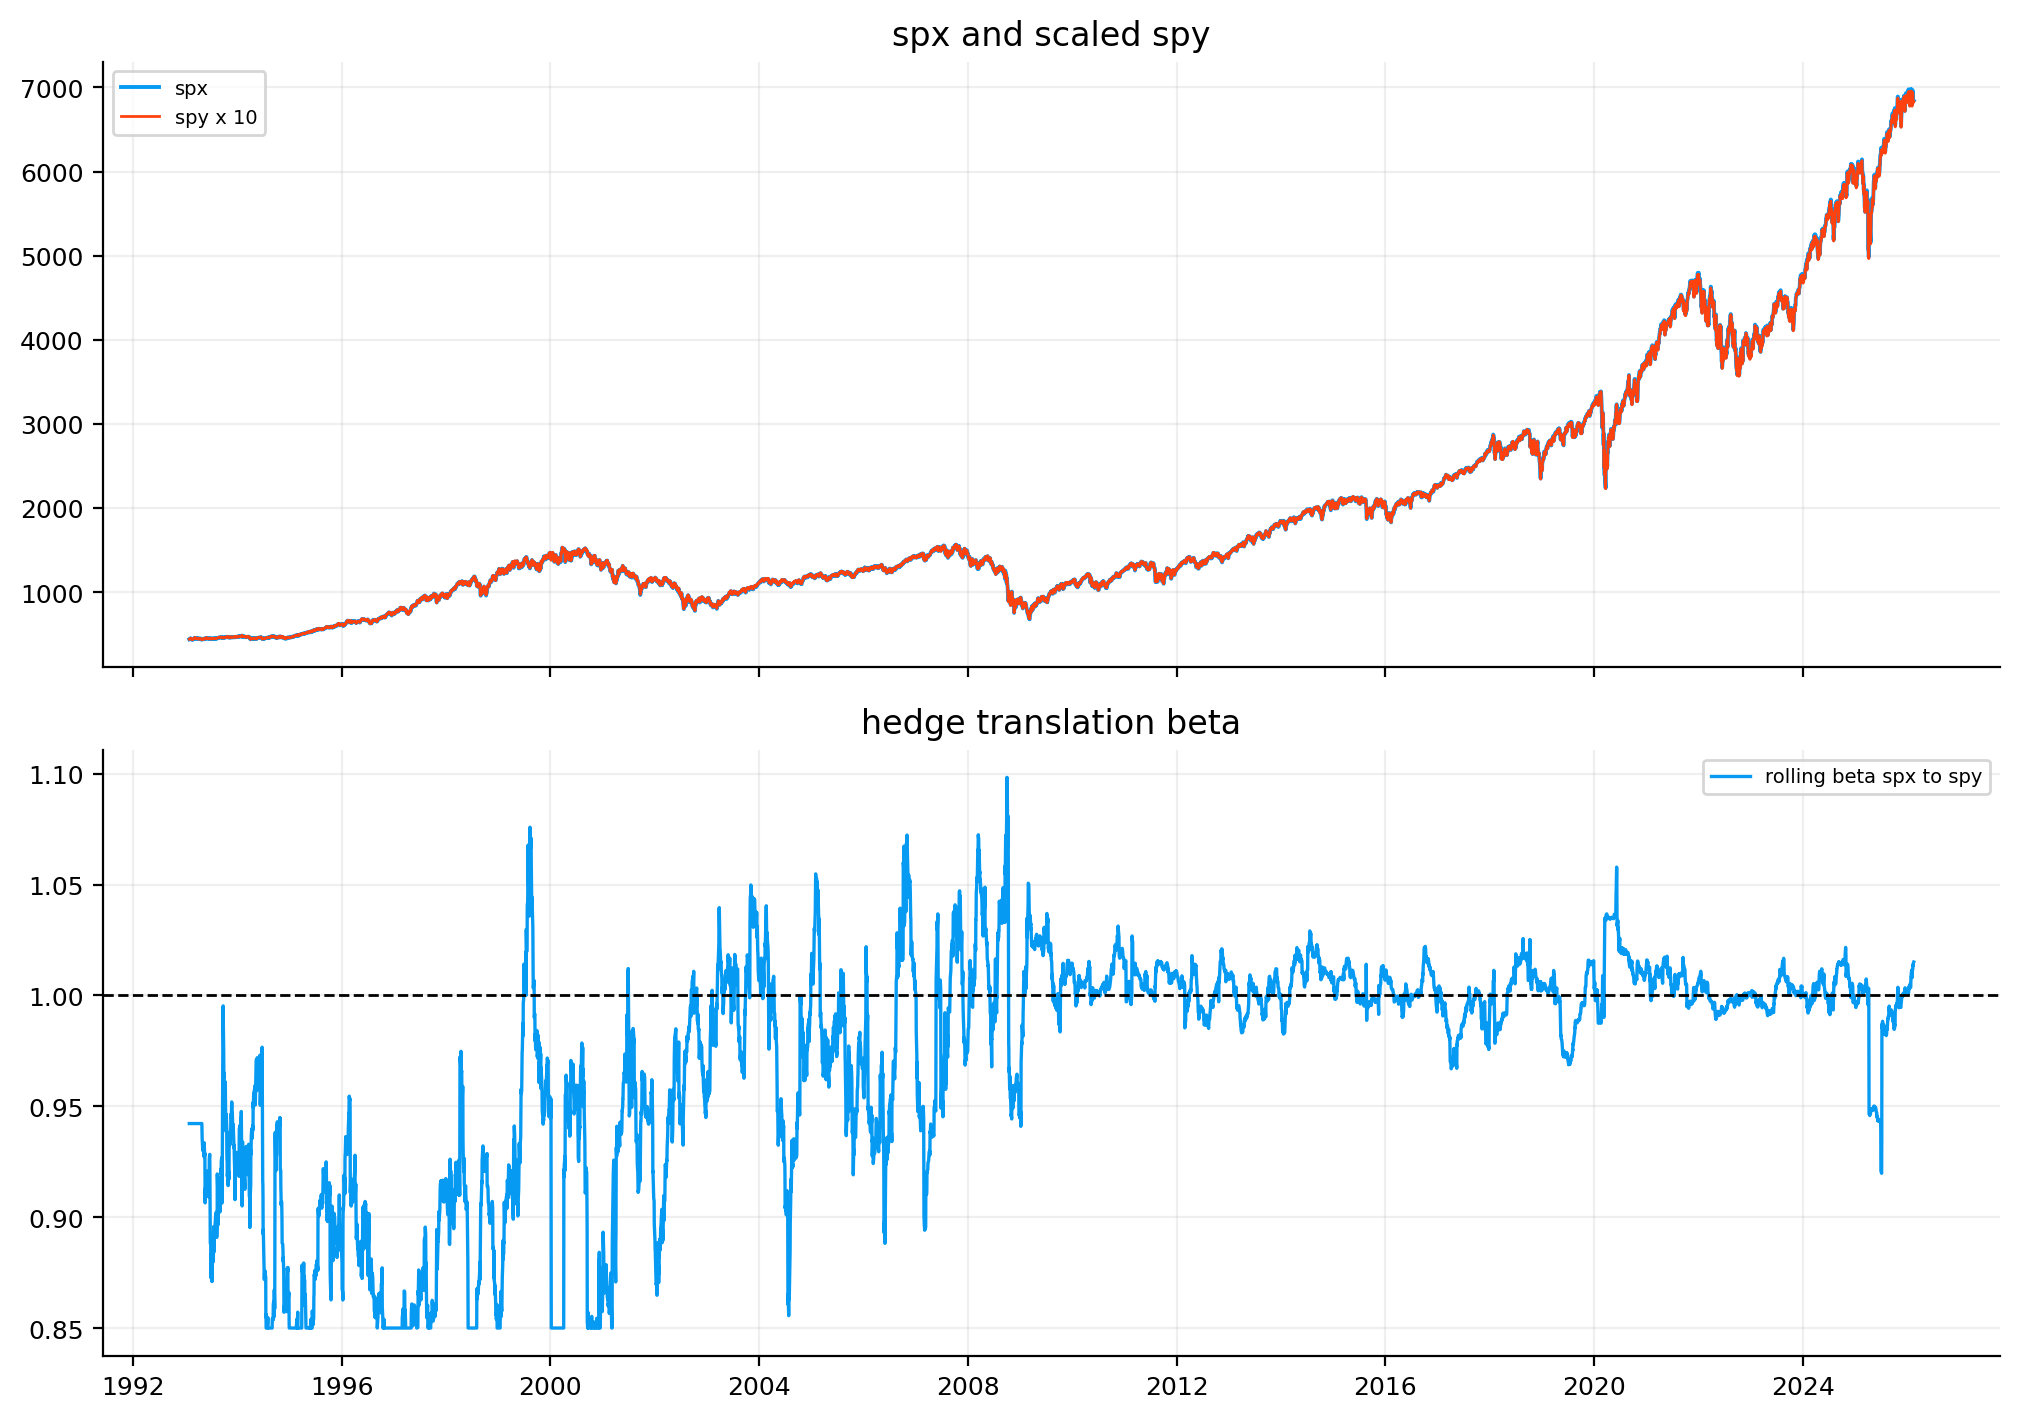

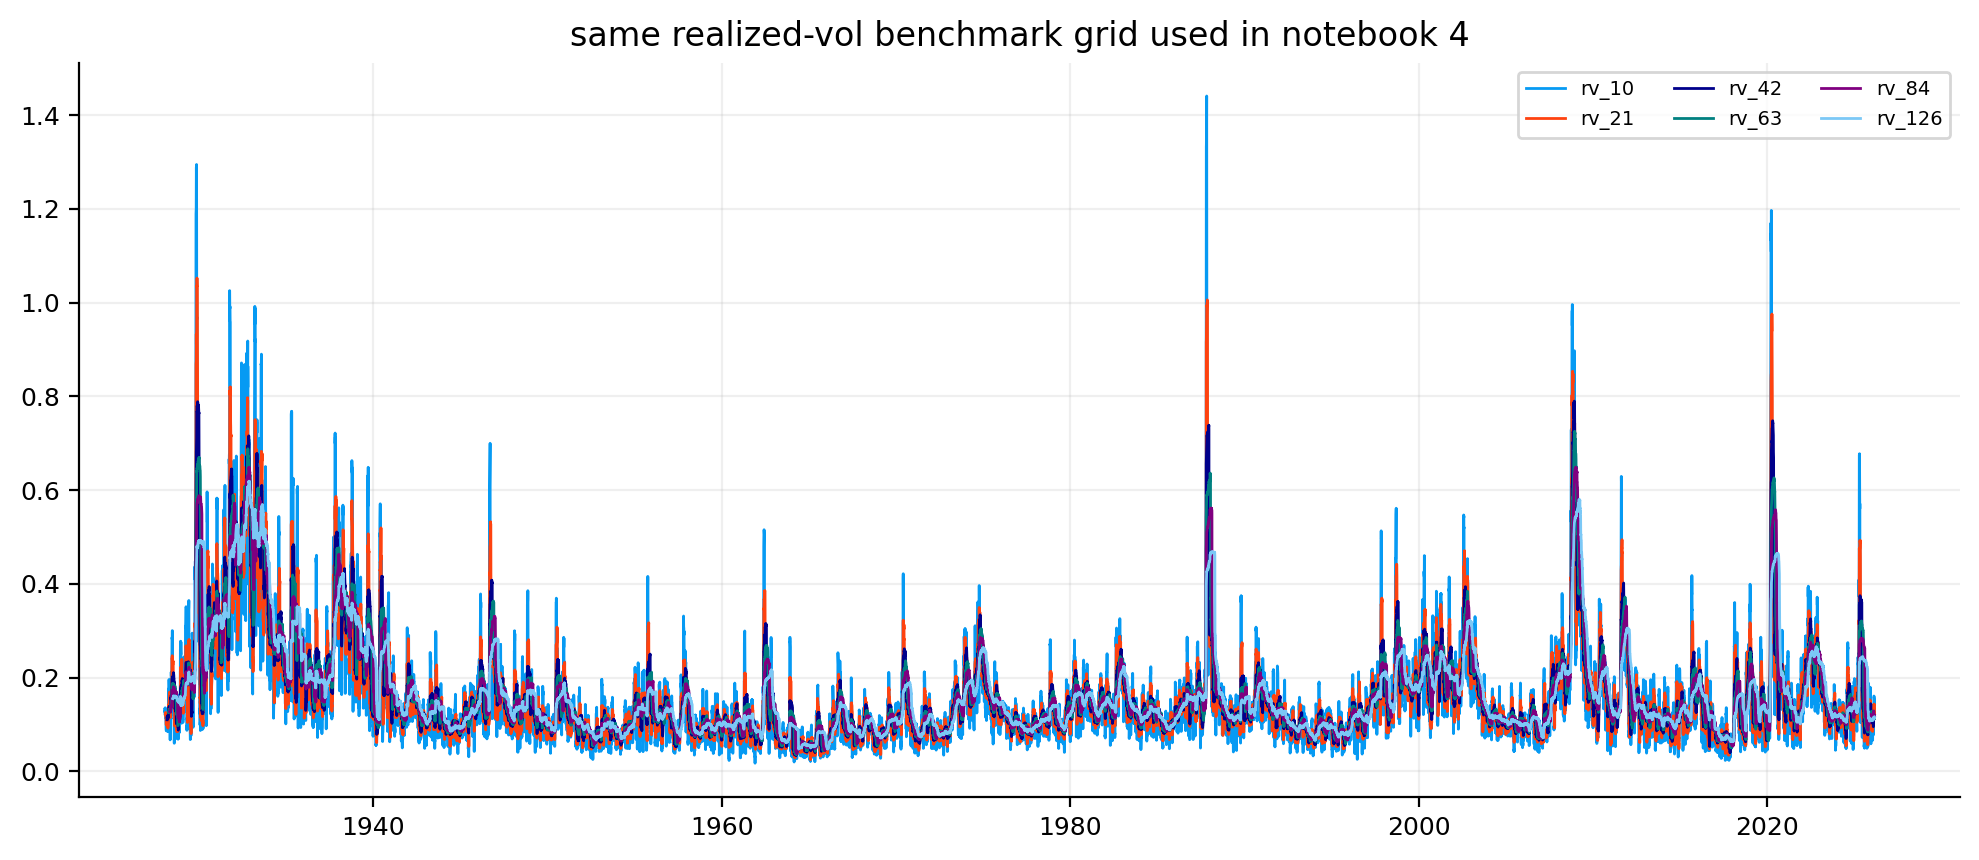

,trade_date,close,rv_10,rv_21,rv_42,rv_63,rv_84,rv_126
24648,2026-02-18,"6,881.310059",0.156038,0.143226,0.116860,0.116754,0.119081,0.115544
24649,2026-02-19,"6,861.890137",0.154597,0.123002,0.113259,0.115322,0.118912,0.115284
24650,2026-02-20,"6,909.509766",0.142389,0.118742,0.112887,0.114648,0.118112,0.115556
24651,2026-02-23,"6,837.750000",0.113501,0.122628,0.114002,0.116603,0.119569,0.116429
24652,2026-02-24,"6,890.069824",0.118736,0.125828,0.114456,0.112737,0.119858,0.115025


In [18]:
rv_windows = [10, 21, 42, 63, 84, 126]
for w in rv_windows:
    df_spx[f"rv_{w}"] = df_spx["ret"].rolling(w).std() * np.sqrt(252.0)

fig, axes = plt.subplots(2, 1, figsize=(10.2, 7.2), sharex=True)
axes[0].plot(df_market["trade_date"], df_market["spx_close"], lw=1.4, label="spx")
axes[0].plot(df_market["trade_date"], df_market["spy_close"] * 10.0, lw=1.0, label="spy x 10")
axes[0].set_title("spx and scaled spy")
axes[0].legend(loc="best")

axes[1].plot(df_market["trade_date"], df_market["beta_spx_to_spy"], lw=1.2, label="rolling beta spx to spy")
axes[1].axhline(1.0, lw=1.0, ls="--", c="black")
axes[1].set_title("hedge translation beta")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10.0, 4.4))
for w in rv_windows:
    ax.plot(df_spx["trade_date"], df_spx[f"rv_{w}"], lw=1.0, label=f"rv_{w}")
ax.set_title("same realized-vol benchmark grid used in notebook 4")
ax.legend(ncol=3, loc="best")
plt.tight_layout()
plt.show()

display(df_spx[["trade_date", "close"] + [f"rv_{w}" for w in rv_windows]].tail())


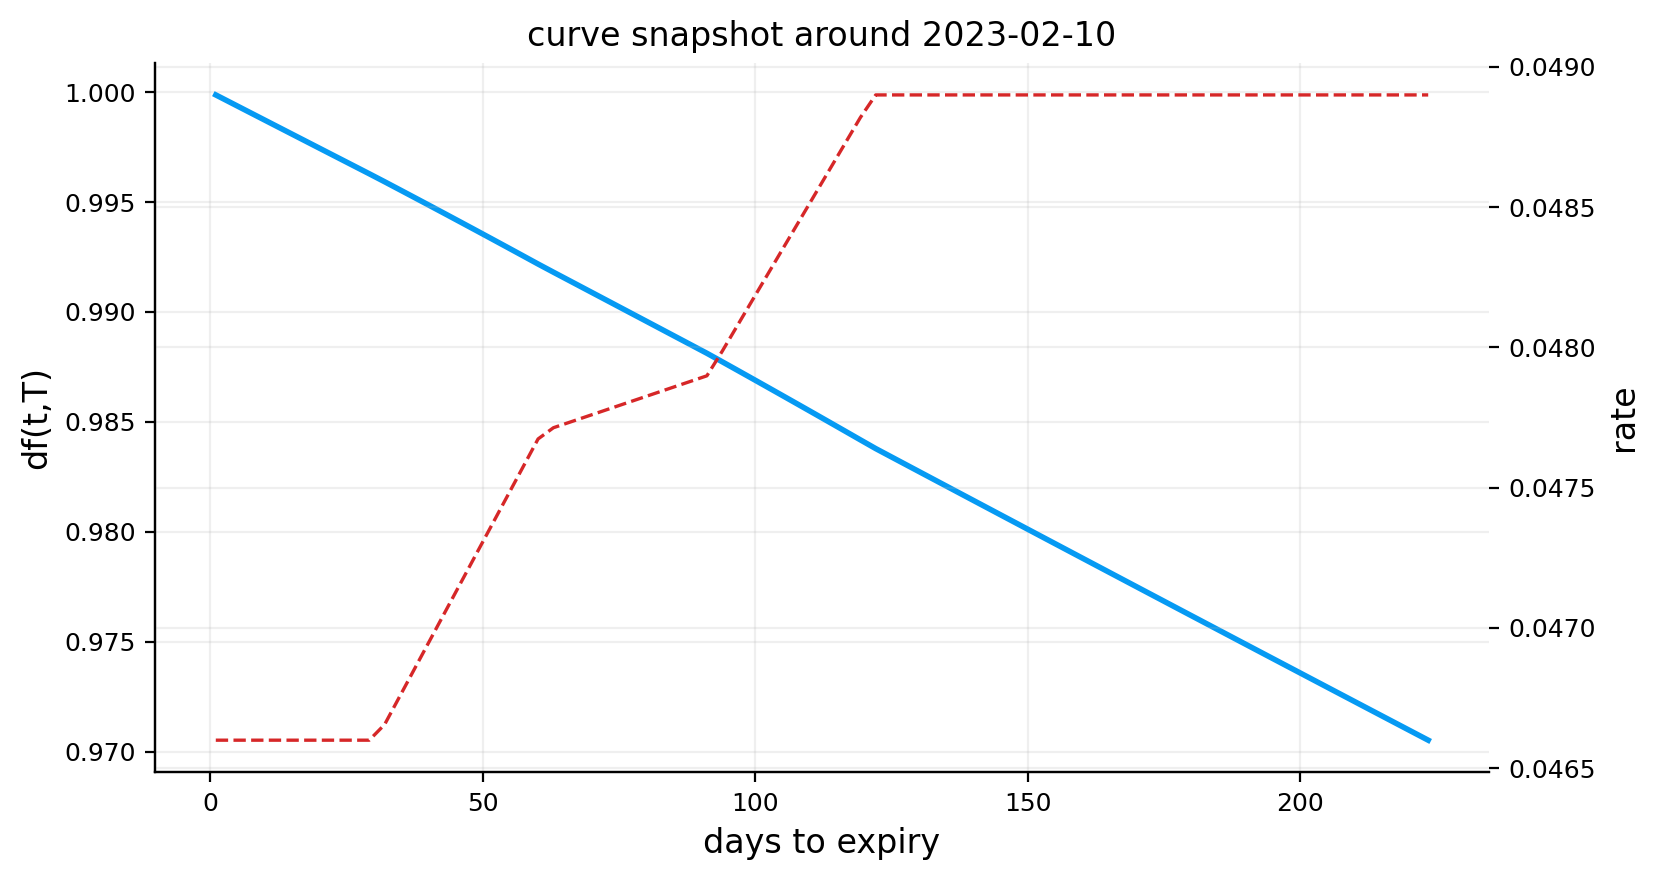

,metric,value
0,sample_date,2023-02-10
1,rate_date_used,2023-02-10
2,zero_rate_30d,0.046600
3,zero_rate_100d,0.048185


In [19]:
def make_rate_grid(df_rates):
    rates = df_rates.copy()
    rates.columns = [str(c).strip().lower() for c in rates.columns]
    if "date" not in rates.columns:
        raise ValueError("rate file must contain a date column")
    rates["date"] = pd.to_datetime(rates["date"], errors="coerce").dt.normalize()
    rates = rates.dropna(subset=["date"]).sort_values("date")

    tenor_map = {
        "1 mo": 1 / 12,
        "2 mo": 2 / 12,
        "3 mo": 3 / 12,
        "4 mo": 4 / 12,
        "6 mo": 6 / 12,
        "1 yr": 1.0,
        "2 yr": 2.0,
        "3 yr": 3.0,
        "5 yr": 5.0,
        "7 yr": 7.0,
        "10 yr": 10.0,
        "20 yr": 20.0,
        "30 yr": 30.0,
    }

    keep = ["date"]
    for col in list(rates.columns):
        if col in tenor_map:
            keep.append(col)
    rates = rates[keep].copy()

    long_rows = []
    for _, row in rates.iterrows():
        d = row["date"]
        for col, tau in tenor_map.items():
            if col in row.index:
                y = pd.to_numeric(row[col], errors="coerce")
                if pd.notna(y):
                    long_rows.append({"date": d, "tau": float(tau), "yield_cc": float(y) / 100.0})
    grid = pd.DataFrame(long_rows).sort_values(["date", "tau"]).reset_index(drop=True)
    return grid


df_rate_grid = make_rate_grid(df_rates)
rate_dates = np.sort(df_rate_grid["date"].dropna().unique())

def resolve_rate_date(trade_date):
    d = pd.Timestamp(trade_date).normalize()
    pos = np.searchsorted(rate_dates, np.datetime64(d), side="right") - 1
    if pos < 0:
        raise ValueError("no rate date available on or before trade date")
    return pd.Timestamp(rate_dates[pos]).normalize()

def interp_zero_cc(trade_date, tau):
    tau = float(np.clip(tau, 1e-10, None))
    d = resolve_rate_date(trade_date)
    g = df_rate_grid[df_rate_grid["date"] == d].sort_values("tau")
    x = g["tau"].to_numpy(dtype=float)
    y = g["yield_cc"].to_numpy(dtype=float)
    if len(x) == 0:
        return np.nan
    if tau <= x.min():
        return float(y[0])
    if tau >= x.max():
        return float(y[-1])
    return float(np.interp(tau, x, y))

def get_df(trade_date, tau):
    tau = np.asarray(tau, dtype=float)
    out = np.empty_like(tau, dtype=float)
    it = np.ndindex(tau.shape)
    for idx in it:
        t = float(np.clip(tau[idx], 1e-10, None))
        r = interp_zero_cc(trade_date, t)
        out[idx] = math.exp(-r * t)
    return out

def get_rate(trade_date, tau):
    tau = np.asarray(tau, dtype=float)
    out = np.empty_like(tau, dtype=float)
    it = np.ndindex(tau.shape)
    for idx in it:
        out[idx] = interp_zero_cc(trade_date, float(np.clip(tau[idx], 1e-10, None)))
    return out

sample_date = df_pairs["trade_date"].dropna().sort_values().iloc[len(df_pairs["trade_date"].dropna().sort_values()) // 2]
tau_grid = np.linspace(1.0 / 365.25, 2.0, 260)
df_grid = get_df(sample_date, tau_grid)
r_grid = np.where(tau_grid > 0, -np.log(np.clip(df_grid, 1e-12, None)) / tau_grid, np.nan)

fig, ax1 = plt.subplots(figsize=(8.4, 4.5))
ax1.plot(tau_grid[:80] * 365.25, df_grid[:80], lw=2.0, label="discount factor")
ax1.set_xlabel("days to expiry")
ax1.set_ylabel("df(t,T)")
ax2 = ax1.twinx()
ax2.plot(tau_grid[:80] * 365.25, r_grid[:80], lw=1.2, ls="--", c="tab:red", label="cc zero rate")
ax2.set_ylabel("rate")
ax1.set_title(f"curve snapshot around {pd.Timestamp(sample_date).date()}")
plt.tight_layout()
plt.show()

display(pd.DataFrame(
    [
        {"metric": "sample_date", "value": str(pd.Timestamp(sample_date).date())},
        {"metric": "rate_date_used", "value": str(resolve_rate_date(sample_date).date())},
        {"metric": "zero_rate_30d", "value": interp_zero_cc(sample_date, 30.0 / 365.25)},
        {"metric": "zero_rate_100d", "value": interp_zero_cc(sample_date, 100.0 / 365.25)},
    ]
))


In [20]:
def weighted_median(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    values = values[mask]
    weights = weights[mask]
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    csum = np.cumsum(weights)
    idx = int(np.searchsorted(csum, 0.5 * weights.sum()))
    idx = int(np.clip(idx, 0, len(values) - 1))
    return float(values[idx])

def cp_is_call(cp):
    arr = np.asarray(cp)
    if arr.ndim == 0:
        return bool(str(arr.item()).lower().startswith("c"))
    return np.char.startswith(np.char.lower(arr.astype(str)), "c")

def bsm_forward_price(cp, df, fwd, strike, tau, sigma):
    tau = np.clip(np.asarray(tau, dtype=float), 1e-12, None)
    sigma = np.clip(np.asarray(sigma, dtype=float), 1e-8, None)
    df = np.asarray(df, dtype=float)
    fwd = np.asarray(fwd, dtype=float)
    strike = np.asarray(strike, dtype=float)
    sqrt_tau = np.sqrt(tau)
    d1 = (np.log(np.clip(fwd, 1e-12, None) / np.clip(strike, 1e-12, None)) + 0.5 * sigma * sigma * tau) / (sigma * sqrt_tau)
    d2 = d1 - sigma * sqrt_tau
    is_call = cp_is_call(cp)
    call_val = df * (fwd * norm.cdf(d1) - strike * norm.cdf(d2))
    put_val = df * (strike * norm.cdf(-d2) - fwd * norm.cdf(-d1))
    return np.where(is_call, call_val, put_val)

def iv_bounds(cp, df, fwd, strike):
    is_call = cp_is_call(cp)
    df = np.asarray(df, dtype=float)
    fwd = np.asarray(fwd, dtype=float)
    strike = np.asarray(strike, dtype=float)
    low_call = df * np.maximum(fwd - strike, 0.0)
    high_call = df * fwd
    low_put = df * np.maximum(strike - fwd, 0.0)
    high_put = df * strike
    low = np.where(is_call, low_call, low_put)
    high = np.where(is_call, high_call, high_put)
    return low, high

iv_status = {
    0: "ok",
    1: "nan_input",
    2: "bounds_violation",
    3: "no_convergence",
}

@njit
def norm_cdf_numba(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

@njit
def norm_pdf_numba(x):
    return 0.3989422804014327 * math.exp(-0.5 * x * x)

@njit
def bsm_price_precomputed_numba(is_call, df, fwd, strike, tau, sqrt_tau, log_fk, sigma):
    sigma = max(sigma, 1e-8)
    d1 = (log_fk + 0.5 * sigma * sigma * tau) / (sigma * sqrt_tau)
    d2 = d1 - sigma * sqrt_tau
    if is_call:
        return df * (fwd * norm_cdf_numba(d1) - strike * norm_cdf_numba(d2))
    return df * (strike * norm_cdf_numba(-d2) - fwd * norm_cdf_numba(-d1))

@njit
def bsm_vega_precomputed_numba(df, fwd, tau, sqrt_tau, log_fk, sigma):
    sigma = max(sigma, 1e-8)
    d1 = (log_fk + 0.5 * sigma * sigma * tau) / (sigma * sqrt_tau)
    return df * fwd * norm_pdf_numba(d1) * sqrt_tau

@njit
def iv_one_precomputed_numba(is_call, price, low, high, guess, df, fwd, strike, tau, sqrt_tau, log_fk):
    if not (
        np.isfinite(price)
        and np.isfinite(low)
        and np.isfinite(high)
        and np.isfinite(df)
        and np.isfinite(fwd)
        and np.isfinite(strike)
        and np.isfinite(tau)
    ):
        return np.nan, 1
    if (price <= 0.0) or (df <= 0.0) or (fwd <= 0.0) or (strike <= 0.0) or (tau <= 0.0):
        return np.nan, 1
    if (price < low - 1e-10) or (price > high + 1e-10):
        return np.nan, 2

    lo = 1e-8
    hi = 5.0
    sigma = min(max(guess, 0.03), 2.0)

    for _ in range(12):
        p = bsm_price_precomputed_numba(is_call, df, fwd, strike, tau, sqrt_tau, log_fk, sigma)
        diff = p - price
        if abs(diff) < 1e-8:
            return sigma, 0

        if diff > 0.0:
            hi = sigma
        else:
            lo = sigma

        v = bsm_vega_precomputed_numba(df, fwd, tau, sqrt_tau, log_fk, sigma)
        if (not np.isfinite(v)) or (v < 1e-8):
            sigma = 0.5 * (lo + hi)
        else:
            nxt = sigma - diff / v
            if np.isfinite(nxt) and (lo < nxt < hi):
                sigma = nxt
            else:
                sigma = 0.5 * (lo + hi)

    for _ in range(28):
        sigma = 0.5 * (lo + hi)
        p = bsm_price_precomputed_numba(is_call, df, fwd, strike, tau, sqrt_tau, log_fk, sigma)
        diff = p - price
        if abs(diff) < 1e-8:
            return sigma, 0
        if diff > 0.0:
            hi = sigma
        else:
            lo = sigma

    return sigma, 3

@njit(parallel=True)
def iv_array_numba(is_call, price, low, high, guess, df, fwd, strike, tau, sqrt_tau, log_fk):
    n = len(price)
    sigma_out = np.empty(n, dtype=np.float64)
    status_out = np.empty(n, dtype=np.int64)
    for i in prange(n):
        sigma_out[i], status_out[i] = iv_one_precomputed_numba(
            is_call[i], price[i], low[i], high[i], guess[i], df[i], fwd[i], strike[i], tau[i], sqrt_tau[i], log_fk[i]
        )
    return sigma_out, status_out

def iv_guess_from_price(price, low, df, fwd, strike, tau):
    intrinsic = np.maximum(price - low, 1e-10)
    scale = np.maximum(df * np.sqrt(np.clip(fwd * strike, 1e-12, None)) * np.sqrt(np.clip(tau, 1e-12, None)), 1e-10)
    guess = np.sqrt(2.0 * np.pi) * intrinsic / scale
    return np.clip(guess, 0.03, 2.0)

def estimate_forward_slice(df_slice, near_band=0.15):
    if df_slice.empty:
        return {"ok": False}
    tau = float(np.nanmedian(df_slice["tau"]))
    trade_date = pd.Timestamp(df_slice["trade_date"].iloc[0]).normalize()
    df_tau = float(get_df(trade_date, np.array([tau]))[0])
    strike = df_slice["strike"].to_numpy(dtype=float)
    c_bid = df_slice["c_bid"].to_numpy(dtype=float)
    c_ask = df_slice["c_ask"].to_numpy(dtype=float)
    c_mid = df_slice["c_mid"].to_numpy(dtype=float)
    p_bid = df_slice["p_bid"].to_numpy(dtype=float)
    p_ask = df_slice["p_ask"].to_numpy(dtype=float)
    p_mid = df_slice["p_mid"].to_numpy(dtype=float)
    w = 1.0 / np.clip((c_ask - c_bid) + (p_ask - p_bid), 1e-6, None)
    f_low = strike + (c_bid - p_ask) / df_tau
    f_high = strike + (c_ask - p_bid) / df_tau
    f_mid = strike + (c_mid - p_mid) / df_tau
    prelim = weighted_median(f_mid, w)
    lm = np.log(np.clip(strike, 1e-12, None) / np.clip(prelim, 1e-12, None))
    core = np.abs(lm) <= near_band
    if core.sum() < 3:
        ord_idx = np.argsort(np.abs(lm))
        core = np.zeros(len(lm), dtype=bool)
        core[ord_idx[: min(6, len(lm))]] = True

    f_hat = weighted_median(f_mid[core], w[core])
    med = np.nanmedian(f_mid[core])
    iqr = np.nanquantile(f_mid[core], 0.75) - np.nanquantile(f_mid[core], 0.25)
    dispersion = float(iqr / max(abs(med), 1e-8))
    feasibility = float(np.mean((f_hat >= f_low) & (f_hat <= f_high)))
    f_low_ref = weighted_median(f_low[core], w[core])
    f_high_ref = weighted_median(f_high[core], w[core])
    if not np.isfinite(f_low_ref):
        f_low_ref = float(np.nanmedian(f_low[core]))
    if not np.isfinite(f_high_ref):
        f_high_ref = float(np.nanmedian(f_high[core]))

    return {
        "ok": np.isfinite(f_hat),
        "trade_date": trade_date,
        "expiry_datetime": pd.Timestamp(df_slice["expiry_datetime"].iloc[0]),
        "tau": tau,
        "df": df_tau,
        "r_short": float(interp_zero_cc(trade_date, 1.0 / 365.25)),
        "f_hat": float(f_hat),
        "f_low_ref": float(f_low_ref),
        "f_high_ref": float(f_high_ref),
        "dispersion": dispersion,
        "feasibility": feasibility,
        "n_obs": int(len(df_slice)),
        "n_core": int(core.sum()),
    }

def implied_rate_dividend(spot, df, fwd, tau):
    tau = np.clip(np.asarray(tau, dtype=float), 1e-12, None)
    spot = np.clip(np.asarray(spot, dtype=float), 1e-12, None)
    df = np.clip(np.asarray(df, dtype=float), 1e-12, None)
    fwd = np.clip(np.asarray(fwd, dtype=float), 1e-12, None)
    rate = -np.log(df) / tau
    div = rate - np.log(fwd / spot) / tau
    carry_disc = np.exp(-div * tau)
    return rate, div, carry_disc


In [21]:
forward_rows = []
for _, grp in df_pairs.groupby(["trade_date", "expiry_datetime"], sort=True):
    est = estimate_forward_slice(grp, near_band=0.12)
    if est.get("ok", False):
        forward_rows.append(est)

df_forward = pd.DataFrame(forward_rows).sort_values(["trade_date", "expiry_datetime"]).reset_index(drop=True)
disp_cut = float(np.nanquantile(df_forward["dispersion"], 0.95)) if len(df_forward) else np.nan
disp_limit = float(max(0.02, disp_cut if np.isfinite(disp_cut) else 0.02))
feas_limit = 0.50
df_forward["forward_quality_ok"] = (df_forward["feasibility"] >= feas_limit) & (df_forward["dispersion"] <= disp_limit)

merge_cols = [
    "trade_date",
    "expiry_datetime",
    "df",
    "r_short",
    "f_hat",
    "f_low_ref",
    "f_high_ref",
    "dispersion",
    "feasibility",
    "n_obs",
    "n_core",
    "forward_quality_ok",
]
df_pairs = df_pairs.merge(df_forward[merge_cols], on=["trade_date", "expiry_datetime"], how="inner")
df_pairs["lm_f"] = np.log(np.clip(df_pairs["strike"], 1e-12, None) / np.clip(df_pairs["f_hat"], 1e-12, None))
df_pairs["dte_days"] = df_pairs["tau"] * 365.25

call_cols = [
    "trade_date", "quote_datetime", "expiry_datetime", "tau", "dte_days", "s", "strike", "pair_id",
    "f_hat", "f_low_ref", "f_high_ref", "df", "r_short", "lm_f", "dispersion", "feasibility", "forward_quality_ok",
    "c_bid", "c_ask", "c_mid", "c_spread", "c_rel_spread", "c_volume",
]
put_cols = [
    "trade_date", "quote_datetime", "expiry_datetime", "tau", "dte_days", "s", "strike", "pair_id",
    "f_hat", "f_low_ref", "f_high_ref", "df", "r_short", "lm_f", "dispersion", "feasibility", "forward_quality_ok",
    "p_bid", "p_ask", "p_mid", "p_spread", "p_rel_spread", "p_volume",
]

df_call = df_pairs[call_cols].copy().rename(
    columns={"c_bid": "bid", "c_ask": "ask", "c_mid": "mid", "c_spread": "spread", "c_rel_spread": "rel_spread", "c_volume": "volume"}
)
df_call["cp"] = "call"
df_call["contract_id"] = df_call["pair_id"] + "_c"

df_put = df_pairs[put_cols].copy().rename(
    columns={"p_bid": "bid", "p_ask": "ask", "p_mid": "mid", "p_spread": "spread", "p_rel_spread": "rel_spread", "p_volume": "volume"}
)
df_put["cp"] = "put"
df_put["contract_id"] = df_put["pair_id"] + "_p"

df_options = pd.concat([df_call, df_put], ignore_index=True).sort_values(["trade_date", "expiry_datetime", "cp", "strike"]).reset_index(drop=True)

df_options = df_options.merge(df_spx[["trade_date"] + [f"rv_{w}" for w in rv_windows]], on="trade_date", how="left")
window_arr = np.array(rv_windows, dtype=float)
days = np.clip(np.round(df_options["tau"] * 365.25).to_numpy(dtype=float), window_arr.min(), window_arr.max())
rv_mat = df_options[[f"rv_{w}" for w in rv_windows]].to_numpy(dtype=float)

realized_vol = np.full(len(df_options), np.nan, dtype=float)
for i in range(len(df_options)):
    row = rv_mat[i]
    mask = np.isfinite(row)
    if mask.sum() == 0:
        continue
    if mask.sum() == 1:
        realized_vol[i] = float(row[mask][0])
        continue
    realized_vol[i] = float(np.interp(days[i], window_arr[mask], row[mask]))

df_options["rv_window"] = days
df_options["realized_vol"] = realized_vol
df_options = df_options[df_options["lm_f"].abs() <= 0.25].copy()
df_options["half_spread"] = 0.5 * np.clip(df_options["ask"] - df_options["bid"], 0.0, None)
df_options = df_options.dropna(subset=["realized_vol"]).reset_index(drop=True)

display(df_options.head())


,trade_date,quote_datetime,expiry_datetime,tau,dte_days,s,strike,pair_id,f_hat,f_low_ref,...,contract_id,rv_10,rv_21,rv_42,rv_63,rv_84,rv_126,rv_window,realized_vol,half_spread
0,2022-01-03,2022-01-03 16:00:00,2022-01-12,0.022815,8.333333,"4,795.570000","4,735.000000",2022-01-12_4735.0,"4,794.250106","4,793.600554",...,2022-01-12_4735.0_c,0.139128,0.162425,0.153529,0.135755,0.139253,0.126950,10.000000,0.139128,3.300000
1,2022-01-03,2022-01-03 16:00:00,2022-01-12,0.022815,8.333333,"4,795.570000","4,740.000000",2022-01-12_4740.0,"4,794.250106","4,793.600554",...,2022-01-12_4740.0_c,0.139128,0.162425,0.153529,0.135755,0.139253,0.126950,10.000000,0.139128,3.100000
2,2022-01-03,2022-01-03 16:00:00,2022-01-12,0.022815,8.333333,"4,795.570000","4,745.000000",2022-01-12_4745.0,"4,794.250106","4,793.600554",...,2022-01-12_4745.0_c,0.139128,0.162425,0.153529,0.135755,0.139253,0.126950,10.000000,0.139128,0.400000
3,2022-01-03,2022-01-03 16:00:00,2022-01-12,0.022815,8.333333,"4,795.570000","4,750.000000",2022-01-12_4750.0,"4,794.250106","4,793.600554",...,2022-01-12_4750.0_c,0.139128,0.162425,0.153529,0.135755,0.139253,0.126950,10.000000,0.139128,0.500000
4,2022-01-03,2022-01-03 16:00:00,2022-01-12,0.022815,8.333333,"4,795.570000","4,755.000000",2022-01-12_4755.0,"4,794.250106","4,793.600554",...,2022-01-12_4755.0_c,0.139128,0.162425,0.153529,0.135755,0.139253,0.126950,10.000000,0.139128,0.300000


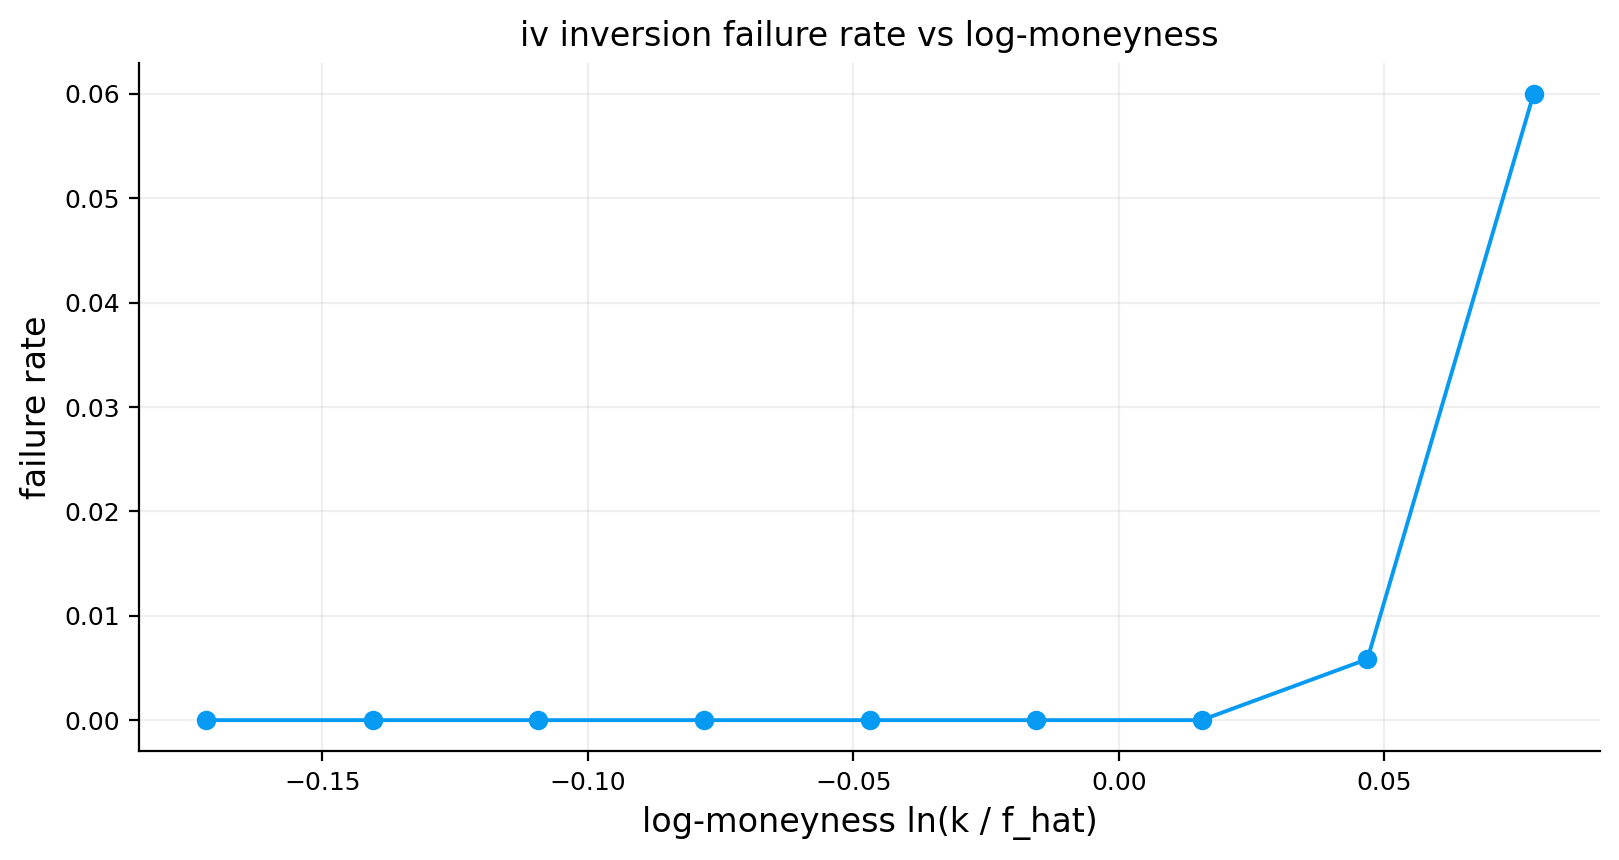

,metric,value
0,total_quotes,"589,436.000000"
1,iv_success_rate,0.999985
2,iv_bid_success_rate,0.999754
3,iv_ask_success_rate,1.000000
4,compile_warmup_sec,8.578635
5,solve_elapsed_sec,0.243640
6,quotes_per_sec,"7,257,880.982007"


In [22]:
t_compile0 = time.time()

n = len(df_options)
cp_arr = df_options["cp"].to_numpy()
is_call_arr = cp_is_call(cp_arr).astype(np.bool_)
mid_arr = df_options["mid"].to_numpy(dtype=float)
bid_arr = df_options["bid"].to_numpy(dtype=float)
ask_arr = df_options["ask"].to_numpy(dtype=float)
df_arr = df_options["df"].to_numpy(dtype=float)
fwd_arr = df_options["f_hat"].to_numpy(dtype=float)
strike_arr = df_options["strike"].to_numpy(dtype=float)
tau_arr = np.clip(df_options["tau"].to_numpy(dtype=float), 1e-12, None)
sqrt_tau_arr = np.sqrt(tau_arr)
log_fk_arr = np.log(np.clip(fwd_arr, 1e-12, None) / np.clip(strike_arr, 1e-12, None))
low_arr, high_arr = iv_bounds(cp_arr, df_arr, fwd_arr, strike_arr)
guess_mid_arr = iv_guess_from_price(mid_arr, low_arr, df_arr, fwd_arr, strike_arr, tau_arr)
guess_bid_arr = iv_guess_from_price(np.maximum(bid_arr, low_arr + 1e-10), low_arr, df_arr, fwd_arr, strike_arr, tau_arr)
guess_ask_arr = iv_guess_from_price(np.minimum(ask_arr, high_arr - 1e-10), low_arr, df_arr, fwd_arr, strike_arr, tau_arr)

warm_n = min(max(1, min(n, 256)), n)
_ = iv_array_numba(
    is_call_arr[:warm_n], mid_arr[:warm_n], low_arr[:warm_n], high_arr[:warm_n], guess_mid_arr[:warm_n],
    df_arr[:warm_n], fwd_arr[:warm_n], strike_arr[:warm_n], tau_arr[:warm_n], sqrt_tau_arr[:warm_n], log_fk_arr[:warm_n]
)
compile_sec = time.time() - t_compile0

t0 = time.time()
iv_mid_arr, iv_status_arr = iv_array_numba(
    is_call_arr, mid_arr, low_arr, high_arr, guess_mid_arr, df_arr, fwd_arr, strike_arr, tau_arr, sqrt_tau_arr, log_fk_arr
)
iv_bid_arr, iv_status_bid_arr = iv_array_numba(
    is_call_arr, bid_arr, low_arr, high_arr, guess_bid_arr, df_arr, fwd_arr, strike_arr, tau_arr, sqrt_tau_arr, log_fk_arr
)
iv_ask_arr, iv_status_ask_arr = iv_array_numba(
    is_call_arr, ask_arr, low_arr, high_arr, guess_ask_arr, df_arr, fwd_arr, strike_arr, tau_arr, sqrt_tau_arr, log_fk_arr
)
elapsed_sec = time.time() - t0

df_options["iv_mid"] = np.where(iv_status_arr == 0, iv_mid_arr, np.nan)
df_options["iv_bid"] = np.where(iv_status_bid_arr == 0, iv_bid_arr, np.nan)
df_options["iv_ask"] = np.where(iv_status_ask_arr == 0, iv_ask_arr, np.nan)
df_options["iv_reason"] = pd.Series(iv_status_arr).map(iv_status).to_numpy()
df_options["iv_ok"] = iv_status_arr == 0
df_options["iv_bid_ok"] = iv_status_bid_arr == 0
df_options["iv_ask_ok"] = iv_status_ask_arr == 0

iv_bid_fill = df_options["iv_bid"].where(df_options["iv_bid_ok"], df_options["iv_mid"])
iv_ask_fill = df_options["iv_ask"].where(df_options["iv_ask_ok"], df_options["iv_mid"])
df_options["iv_bid_fill"] = np.minimum(iv_bid_fill, df_options["iv_mid"])
df_options["iv_ask_fill"] = np.maximum(iv_ask_fill, df_options["iv_mid"])

tmp = df_options.copy()
tmp["lm_bin"] = pd.cut(tmp["lm_f"], bins=np.linspace(-0.25, 0.25, 17), include_lowest=True)
fail_curve = tmp.groupby("lm_bin", observed=False)["iv_ok"].agg(["mean", "size"]).reset_index()
fail_curve["fail_rate"] = 1.0 - fail_curve["mean"]
fail_curve["lm_mid"] = fail_curve["lm_bin"].apply(lambda b: b.mid if pd.notna(b) else np.nan).astype(float)

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.plot(fail_curve["lm_mid"], fail_curve["fail_rate"], marker="o", lw=1.4)
ax.set_title("iv inversion failure rate vs log-moneyness")
ax.set_xlabel("log-moneyness ln(k / f_hat)")
ax.set_ylabel("failure rate")
plt.tight_layout()
plt.show()

display(pd.DataFrame(
    [
        {"metric": "total_quotes", "value": int(len(df_options))},
        {"metric": "iv_success_rate", "value": float(np.nanmean(df_options["iv_ok"]))},
        {"metric": "iv_bid_success_rate", "value": float(np.nanmean(df_options["iv_bid_ok"]))},
        {"metric": "iv_ask_success_rate", "value": float(np.nanmean(df_options["iv_ask_ok"]))},
        {"metric": "compile_warmup_sec", "value": float(compile_sec)},
        {"metric": "solve_elapsed_sec", "value": float(elapsed_sec)},
        {"metric": "quotes_per_sec", "value": float(3.0 * len(df_options) / max(elapsed_sec, 1e-9))},
    ]
))


In [23]:
returns_series = df_market.loc[df_market["spx_ret"].notna(), ["trade_date", "spx_ret"]].copy().reset_index(drop=True)
ret_pct = 100.0 * returns_series["spx_ret"].to_numpy(dtype=float)

def garch_backcast(resids, decay=0.94, horizon=75):
    x = np.asarray(resids, dtype=float) ** 2
    n = min(len(x), horizon)
    if n == 0:
        return 1.0
    w = decay ** np.arange(n)
    w = w / w.sum()
    return float(np.sum(w * x[:n][::-1]))

def garch11_filter_backcast(returns_pct, omega, alpha, beta, backcast=None):
    eps = np.asarray(returns_pct, dtype=float)
    n = len(eps)
    sigma2 = np.empty(n, dtype=float)
    if backcast is None:
        backcast = garch_backcast(eps)
    sigma2[0] = max(float(backcast), 1e-8)
    for t in range(1, n):
        sigma2[t] = omega + alpha * eps[t - 1] ** 2 + beta * sigma2[t - 1]
        if sigma2[t] < 1e-10:
            sigma2[t] = 1e-10
    return sigma2

def garch11_negloglik_normal(params, returns_pct, backcast=None):
    omega, alpha, beta = [float(x) for x in params]
    if omega <= 0.0 or alpha < 0.0 or beta < 0.0 or alpha + beta >= 0.999:
        return 1e16
    sigma2 = garch11_filter_backcast(returns_pct, omega, alpha, beta, backcast=backcast)
    ll = -0.5 * (np.log(2.0 * np.pi) + np.log(sigma2) + (returns_pct ** 2) / sigma2)
    val = -float(np.sum(ll))
    if not np.isfinite(val):
        return 1e16
    return val

def garch11_multi_horizon_variance(last_sigma2, last_eps, omega, alpha, beta, horizons):
    horizons = list(sorted(set(int(h) for h in horizons)))
    out = {}
    h1 = omega + alpha * float(last_eps) ** 2 + beta * float(last_sigma2)
    out[1] = h1
    unc = omega / max(1.0 - alpha - beta, 1e-8)
    prev = h1
    for h in range(2, max(horizons) + 1):
        prev = omega + (alpha + beta) * prev
        out[h] = prev
    return {h: out[h] for h in horizons}

def fit_manual_garch11_normal(returns_pct):
    y = np.asarray(returns_pct, dtype=float)
    y = y[np.isfinite(y)]
    backcast = garch_backcast(y)
    var0 = float(np.var(y, ddof=1))
    var0 = max(var0, 1e-6)

    starts = []
    for alpha0, beta0 in [(0.05, 0.90), (0.08, 0.90), (0.10, 0.85), (0.03, 0.95), (0.12, 0.80)]:
        if alpha0 + beta0 >= 0.999:
            continue
        omega0 = max((1.0 - alpha0 - beta0) * var0, 1e-8)
        starts.append(np.array([omega0, alpha0, beta0], dtype=float))

    bounds = [(1e-12, 100.0 * var0), (1e-8, 0.999), (1e-8, 0.999)]
    cons = [{"type": "ineq", "fun": lambda x: 0.999 - x[1] - x[2]}]

    best = None
    for x0 in starts:
        try:
            res = minimize(
                garch11_negloglik_normal,
                x0=x0,
                args=(y, backcast),
                method="SLSQP",
                bounds=bounds,
                constraints=cons,
                options={"maxiter": 2000, "ftol": 1e-12},
            )
            if best is None or res.fun < best.fun:
                best = res
        except Exception:
            continue

    if best is None:
        raise RuntimeError("manual garch fit failed")

    omega, alpha, beta = [float(v) for v in best.x]
    sigma2 = garch11_filter_backcast(y, omega, alpha, beta, backcast=backcast)
    std_resid = y / np.sqrt(np.clip(sigma2, 1e-12, None))
    ll = -garch11_negloglik_normal([omega, alpha, beta], y, backcast)
    n = len(y)
    k = 3

    return {
        "success": bool(best.success),
        "message": str(best.message),
        "omega": omega,
        "alpha": alpha,
        "beta": beta,
        "persistence": alpha + beta,
        "backcast": backcast,
        "sigma2": sigma2,
        "std_resid": std_resid,
        "negloglik": -ll,
        "loglik": ll,
        "aic": 2.0 * k - 2.0 * ll,
        "bic": math.log(n) * k - 2.0 * ll,
        "unc_var": omega / max(1.0 - alpha - beta, 1e-8),
    }

manual_fit = fit_manual_garch11_normal(ret_pct)

am_manual_check = arch_model(ret_pct, mean="Zero", vol="GARCH", p=1, q=1, dist="normal", rescale=False)
res_manual_check = am_manual_check.fit(disp="off", show_warning=False)

display(pd.DataFrame(
    [
        {
            "model": "manual_garch11_normal",
            "success": manual_fit["success"],
            "omega": manual_fit["omega"],
            "alpha": manual_fit["alpha"],
            "beta": manual_fit["beta"],
            "persistence": manual_fit["persistence"],
            "unc_var_pct2": manual_fit["unc_var"],
            "aic": manual_fit["aic"],
            "bic": manual_fit["bic"],
        },
        {
            "model": "arch_garch11_normal",
            "success": True,
            "omega": float(res_manual_check.params.get("omega", np.nan)),
            "alpha": float(res_manual_check.params.get("alpha[1]", np.nan)),
            "beta": float(res_manual_check.params.get("beta[1]", np.nan)),
            "persistence": float(res_manual_check.params.get("alpha[1]", np.nan) + res_manual_check.params.get("beta[1]", np.nan)),
            "unc_var_pct2": float(res_manual_check.params.get("omega", np.nan) / max(1.0 - res_manual_check.params.get("alpha[1]", np.nan) - res_manual_check.params.get("beta[1]", np.nan), 1e-8)),
            "aic": float(res_manual_check.aic),
            "bic": float(res_manual_check.bic),
        },
    ]
))


,model,success,omega,alpha,beta,persistence,unc_var_pct2,aic,bic
0,manual_garch11_normal,True,0.019525,0.107038,0.877546,0.984584,1.266600,"22,346.619271","22,367.698163"
1,arch_garch11_normal,True,0.019346,0.106629,0.878081,0.984710,1.265330,"22,345.576370","22,366.655262"


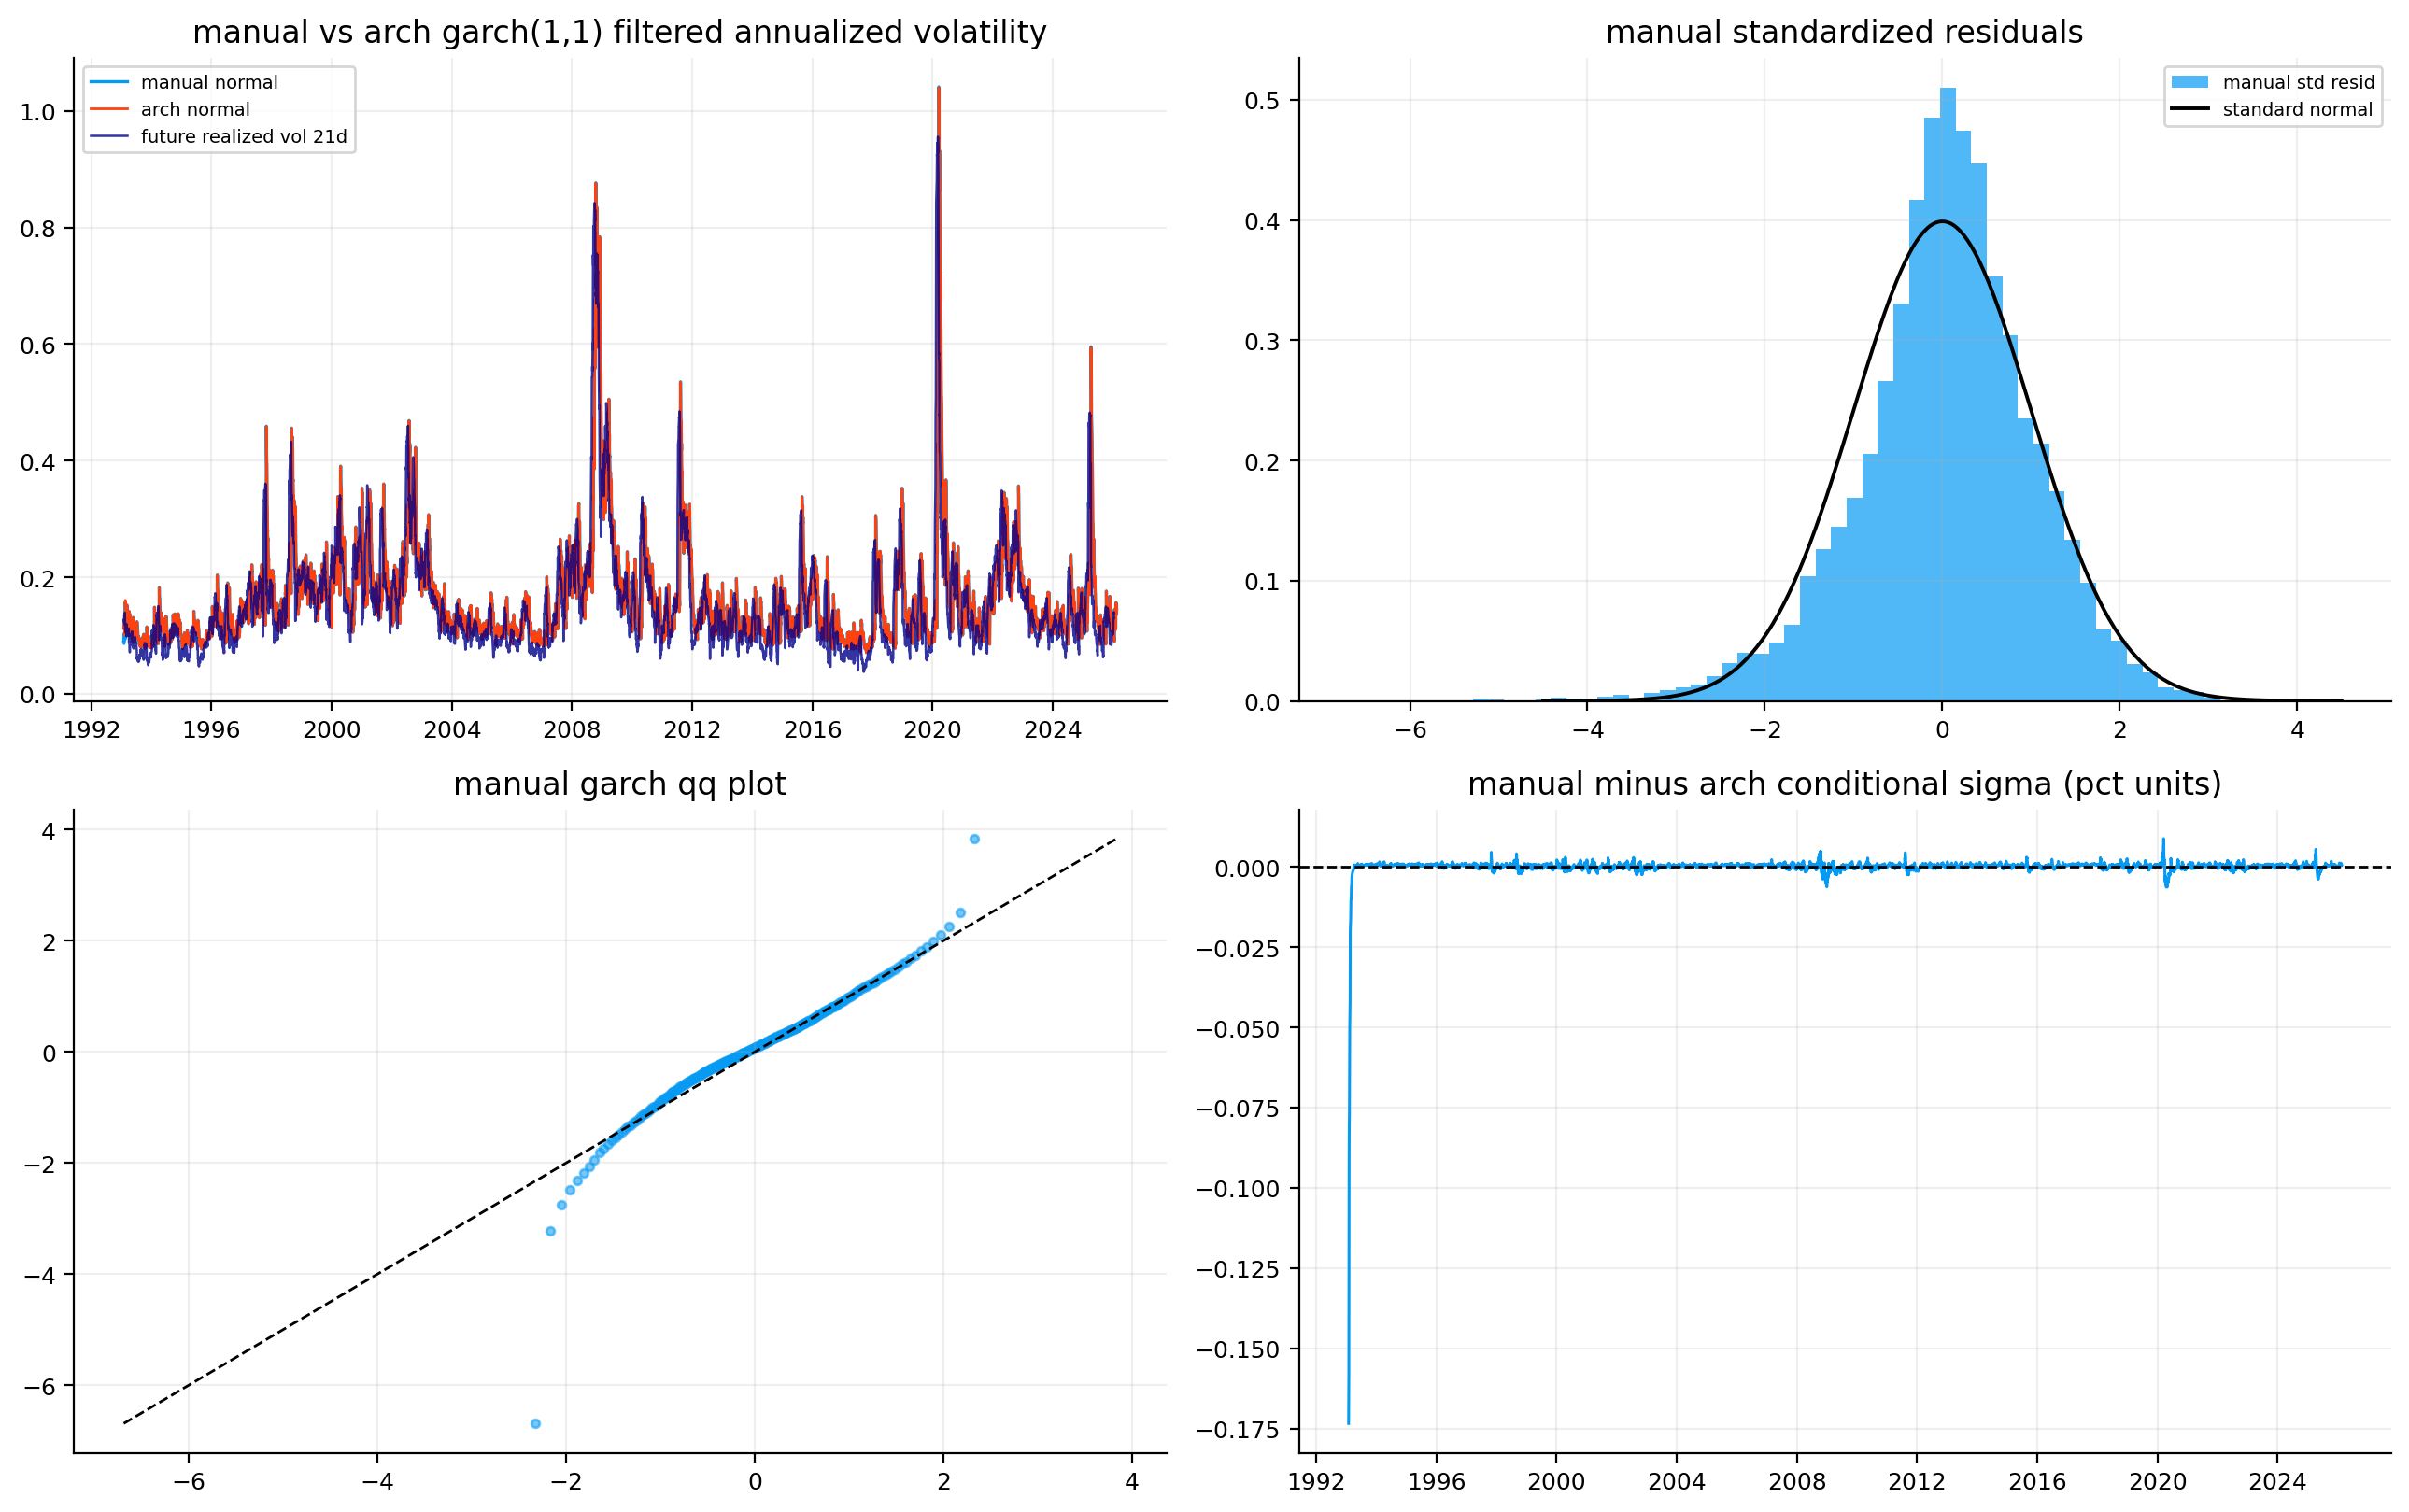

,metric,value
0,manual_arch_param_abs_diff_omega,0.000179
1,manual_arch_param_abs_diff_alpha,0.000409
2,manual_arch_param_abs_diff_beta,0.000535
3,manual_arch_sigma_corr,0.999974


In [24]:
manual_dates = returns_series["trade_date"].reset_index(drop=True)
arch_cond_vol = np.asarray(res_manual_check.conditional_volatility, dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(13.0, 8.2))
axes[0, 0].plot(manual_dates, np.sqrt(252.0) * np.sqrt(manual_fit["sigma2"]) / 100.0, lw=1.2, label="manual normal")
axes[0, 0].plot(manual_dates, np.sqrt(252.0) * arch_cond_vol / 100.0, lw=1.0, label="arch normal")
axes[0, 0].plot(df_market["trade_date"], df_market["rv_vol_fwd_21"], lw=0.9, alpha=0.8, label="future realized vol 21d")
axes[0, 0].set_title("manual vs arch garch(1,1) filtered annualized volatility")
axes[0, 0].legend(loc="best")

axes[0, 1].hist(manual_fit["std_resid"], bins=60, alpha=0.70, density=True, label="manual std resid")
x = np.linspace(-4.5, 4.5, 300)
axes[0, 1].plot(x, norm.pdf(x), lw=1.4, c="black", label="standard normal")
axes[0, 1].set_title("manual standardized residuals")
axes[0, 1].legend(loc="best")

q_grid = np.linspace(0.01, 0.99, 200)
norm_q = norm.ppf(q_grid)
std_resid_manual = np.sort(pd.Series(manual_fit["std_resid"]).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float))
idx = np.linspace(0, len(std_resid_manual) - 1, len(norm_q)).astype(int)
axes[1, 0].scatter(norm_q, std_resid_manual[idx], s=10, alpha=0.55)
lo = min(norm_q.min(), std_resid_manual[idx].min())
hi = max(norm_q.max(), std_resid_manual[idx].max())
axes[1, 0].plot([lo, hi], [lo, hi], ls="--", lw=1.0, c="black")
axes[1, 0].set_title("manual garch qq plot")

sigma_diff = np.sqrt(manual_fit["sigma2"]) - arch_cond_vol
axes[1, 1].plot(manual_dates, sigma_diff, lw=1.1)
axes[1, 1].axhline(0.0, lw=1.0, ls="--", c="black")
axes[1, 1].set_title("manual minus arch conditional sigma (pct units)")

plt.tight_layout()
plt.show()

display(pd.DataFrame(
    [
        {"metric": "manual_arch_param_abs_diff_omega", "value": abs(manual_fit["omega"] - float(res_manual_check.params.get("omega", np.nan)))},
        {"metric": "manual_arch_param_abs_diff_alpha", "value": abs(manual_fit["alpha"] - float(res_manual_check.params.get("alpha[1]", np.nan)))},
        {"metric": "manual_arch_param_abs_diff_beta", "value": abs(manual_fit["beta"] - float(res_manual_check.params.get("beta[1]", np.nan)))},
        {"metric": "manual_arch_sigma_corr", "value": float(np.corrcoef(np.sqrt(manual_fit["sigma2"]), arch_cond_vol)[0, 1])},
    ]
))


In [25]:
def fit_arch_model(returns_pct, vol, p, q, dist, o=0):
    model = arch_model(
        returns_pct,
        mean="Zero",
        vol=vol,
        p=p,
        o=o,
        q=q,
        dist=dist,
        rescale=False,
    )
    res = model.fit(disp="off", show_warning=False)
    return model, res

model_specs = [
    {"name": "garch11_normal", "vol": "GARCH", "p": 1, "o": 0, "q": 1, "dist": "normal"},
    {"name": "garch11_student", "vol": "GARCH", "p": 1, "o": 0, "q": 1, "dist": "t"},
    {"name": "garch22_normal", "vol": "GARCH", "p": 2, "o": 0, "q": 2, "dist": "normal"},
    {"name": "garch22_student", "vol": "GARCH", "p": 2, "o": 0, "q": 2, "dist": "t"},
    {"name": "egarch11_normal", "vol": "EGARCH", "p": 1, "o": 0, "q": 1, "dist": "normal"},
    {"name": "egarch11_student", "vol": "EGARCH", "p": 1, "o": 0, "q": 1, "dist": "t"},
    {"name": "gjr11_normal", "vol": "GARCH", "p": 1, "o": 1, "q": 1, "dist": "normal"},
    {"name": "gjr11_student", "vol": "GARCH", "p": 1, "o": 1, "q": 1, "dist": "t"},
    {"name": "figarch11_normal", "vol": "FIGARCH", "p": 1, "o": 0, "q": 1, "dist": "normal"},
    {"name": "figarch11_student", "vol": "FIGARCH", "p": 1, "o": 0, "q": 1, "dist": "t"},
]

full_sample_fits = {}
fit_rows = []

for spec in model_specs:
    try:
        model, res = fit_arch_model(
            returns_pct=ret_pct,
            vol=spec["vol"],
            p=spec["p"],
            o=spec["o"],
            q=spec["q"],
            dist=spec["dist"],
        )
        full_sample_fits[spec["name"]] = {"model": model, "res": res, "spec": spec}
        params = res.params.to_dict()
        fit_rows.append(
            {
                "model": spec["name"],
                "loglik": float(res.loglikelihood),
                "aic": float(res.aic),
                "bic": float(res.bic),
                "omega": float(params.get("omega", np.nan)),
                "alpha1": float(params.get("alpha[1]", np.nan)),
                "alpha2": float(params.get("alpha[2]", np.nan)),
                "gamma1": float(params.get("gamma[1]", np.nan)),
                "beta1": float(params.get("beta[1]", np.nan)),
                "beta2": float(params.get("beta[2]", np.nan)),
                "nu": float(params.get("nu", np.nan)),
            }
        )
    except Exception as e:
        fit_rows.append({"model": spec["name"], "loglik": np.nan, "aic": np.nan, "bic": np.nan, "error": str(e)})

df_full_sample_fit = pd.DataFrame(fit_rows).sort_values(["aic", "bic"]).reset_index(drop=True)
display(df_full_sample_fit)


,model,loglik,aic,bic,omega,alpha1,alpha2,gamma1,beta1,beta2,nu
0,gjr11_student,"-10,830.181139","21,670.362278","21,705.493764",0.019146,0.000000,NaN,0.200524,0.889106,NaN,7.113589
1,figarch11_student,"-10,958.760497","21,927.520993","21,962.652480",0.026287,NaN,NaN,NaN,NaN,NaN,6.321941
2,garch22_student,"-10,973.305017","21,958.610034","22,000.767818",0.019755,0.061161,0.094940,NaN,0.534312,0.300974,6.335397
3,garch11_student,"-10,980.217019","21,968.434039","21,996.539228",0.011994,0.103092,NaN,NaN,0.891961,NaN,6.365076
4,egarch11_student,"-10,990.293253","21,988.586506","22,016.691696",0.008846,0.210101,NaN,NaN,0.985682,NaN,6.176716
5,gjr11_normal,"-11,000.723303","22,009.446606","22,037.551795",0.021626,0.000000,NaN,0.172934,0.895328,NaN,NaN
6,figarch11_normal,"-11,150.466723","22,308.933445","22,337.038635",0.035697,NaN,NaN,NaN,NaN,NaN,NaN
7,garch22_normal,"-11,161.509042","22,333.018083","22,368.149570",0.036758,0.079022,0.116720,NaN,0.141918,0.633063,NaN
8,garch11_normal,"-11,169.788185","22,345.576370","22,366.655262",0.019346,0.106629,NaN,NaN,0.878081,NaN,NaN
9,egarch11_normal,"-11,197.631140","22,401.262279","22,422.341171",0.007310,0.215382,NaN,NaN,0.977667,NaN,NaN


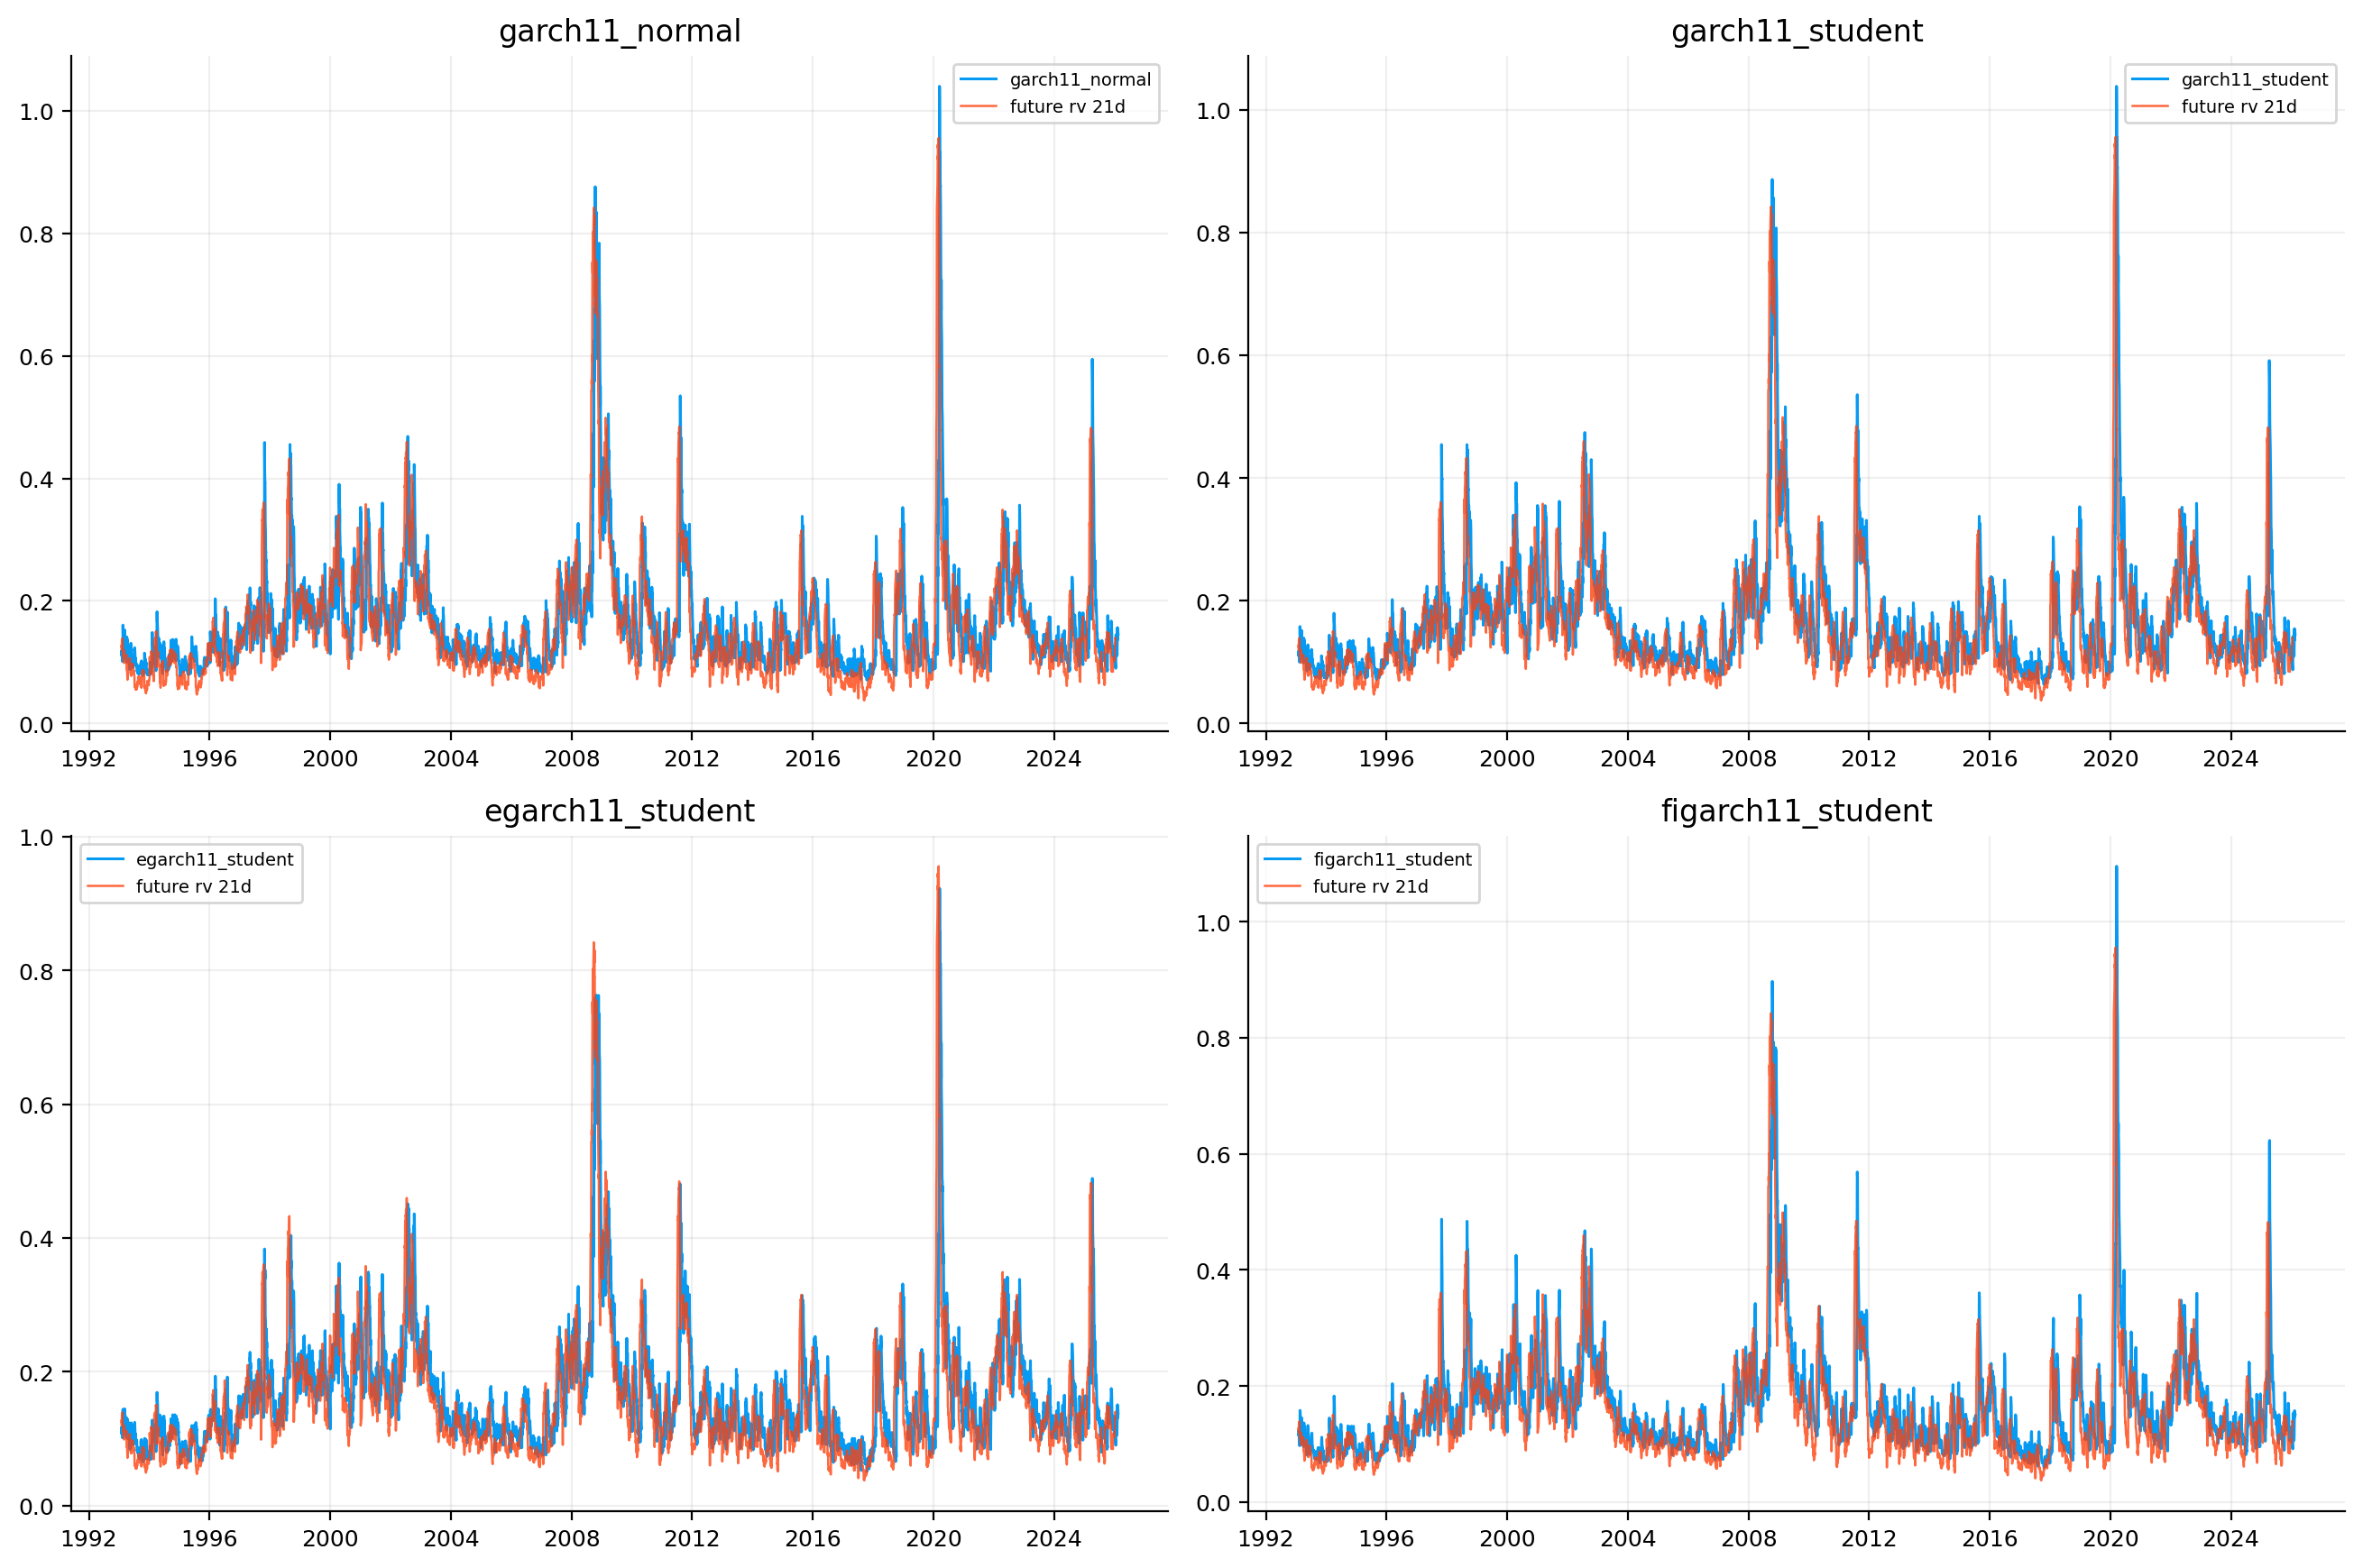

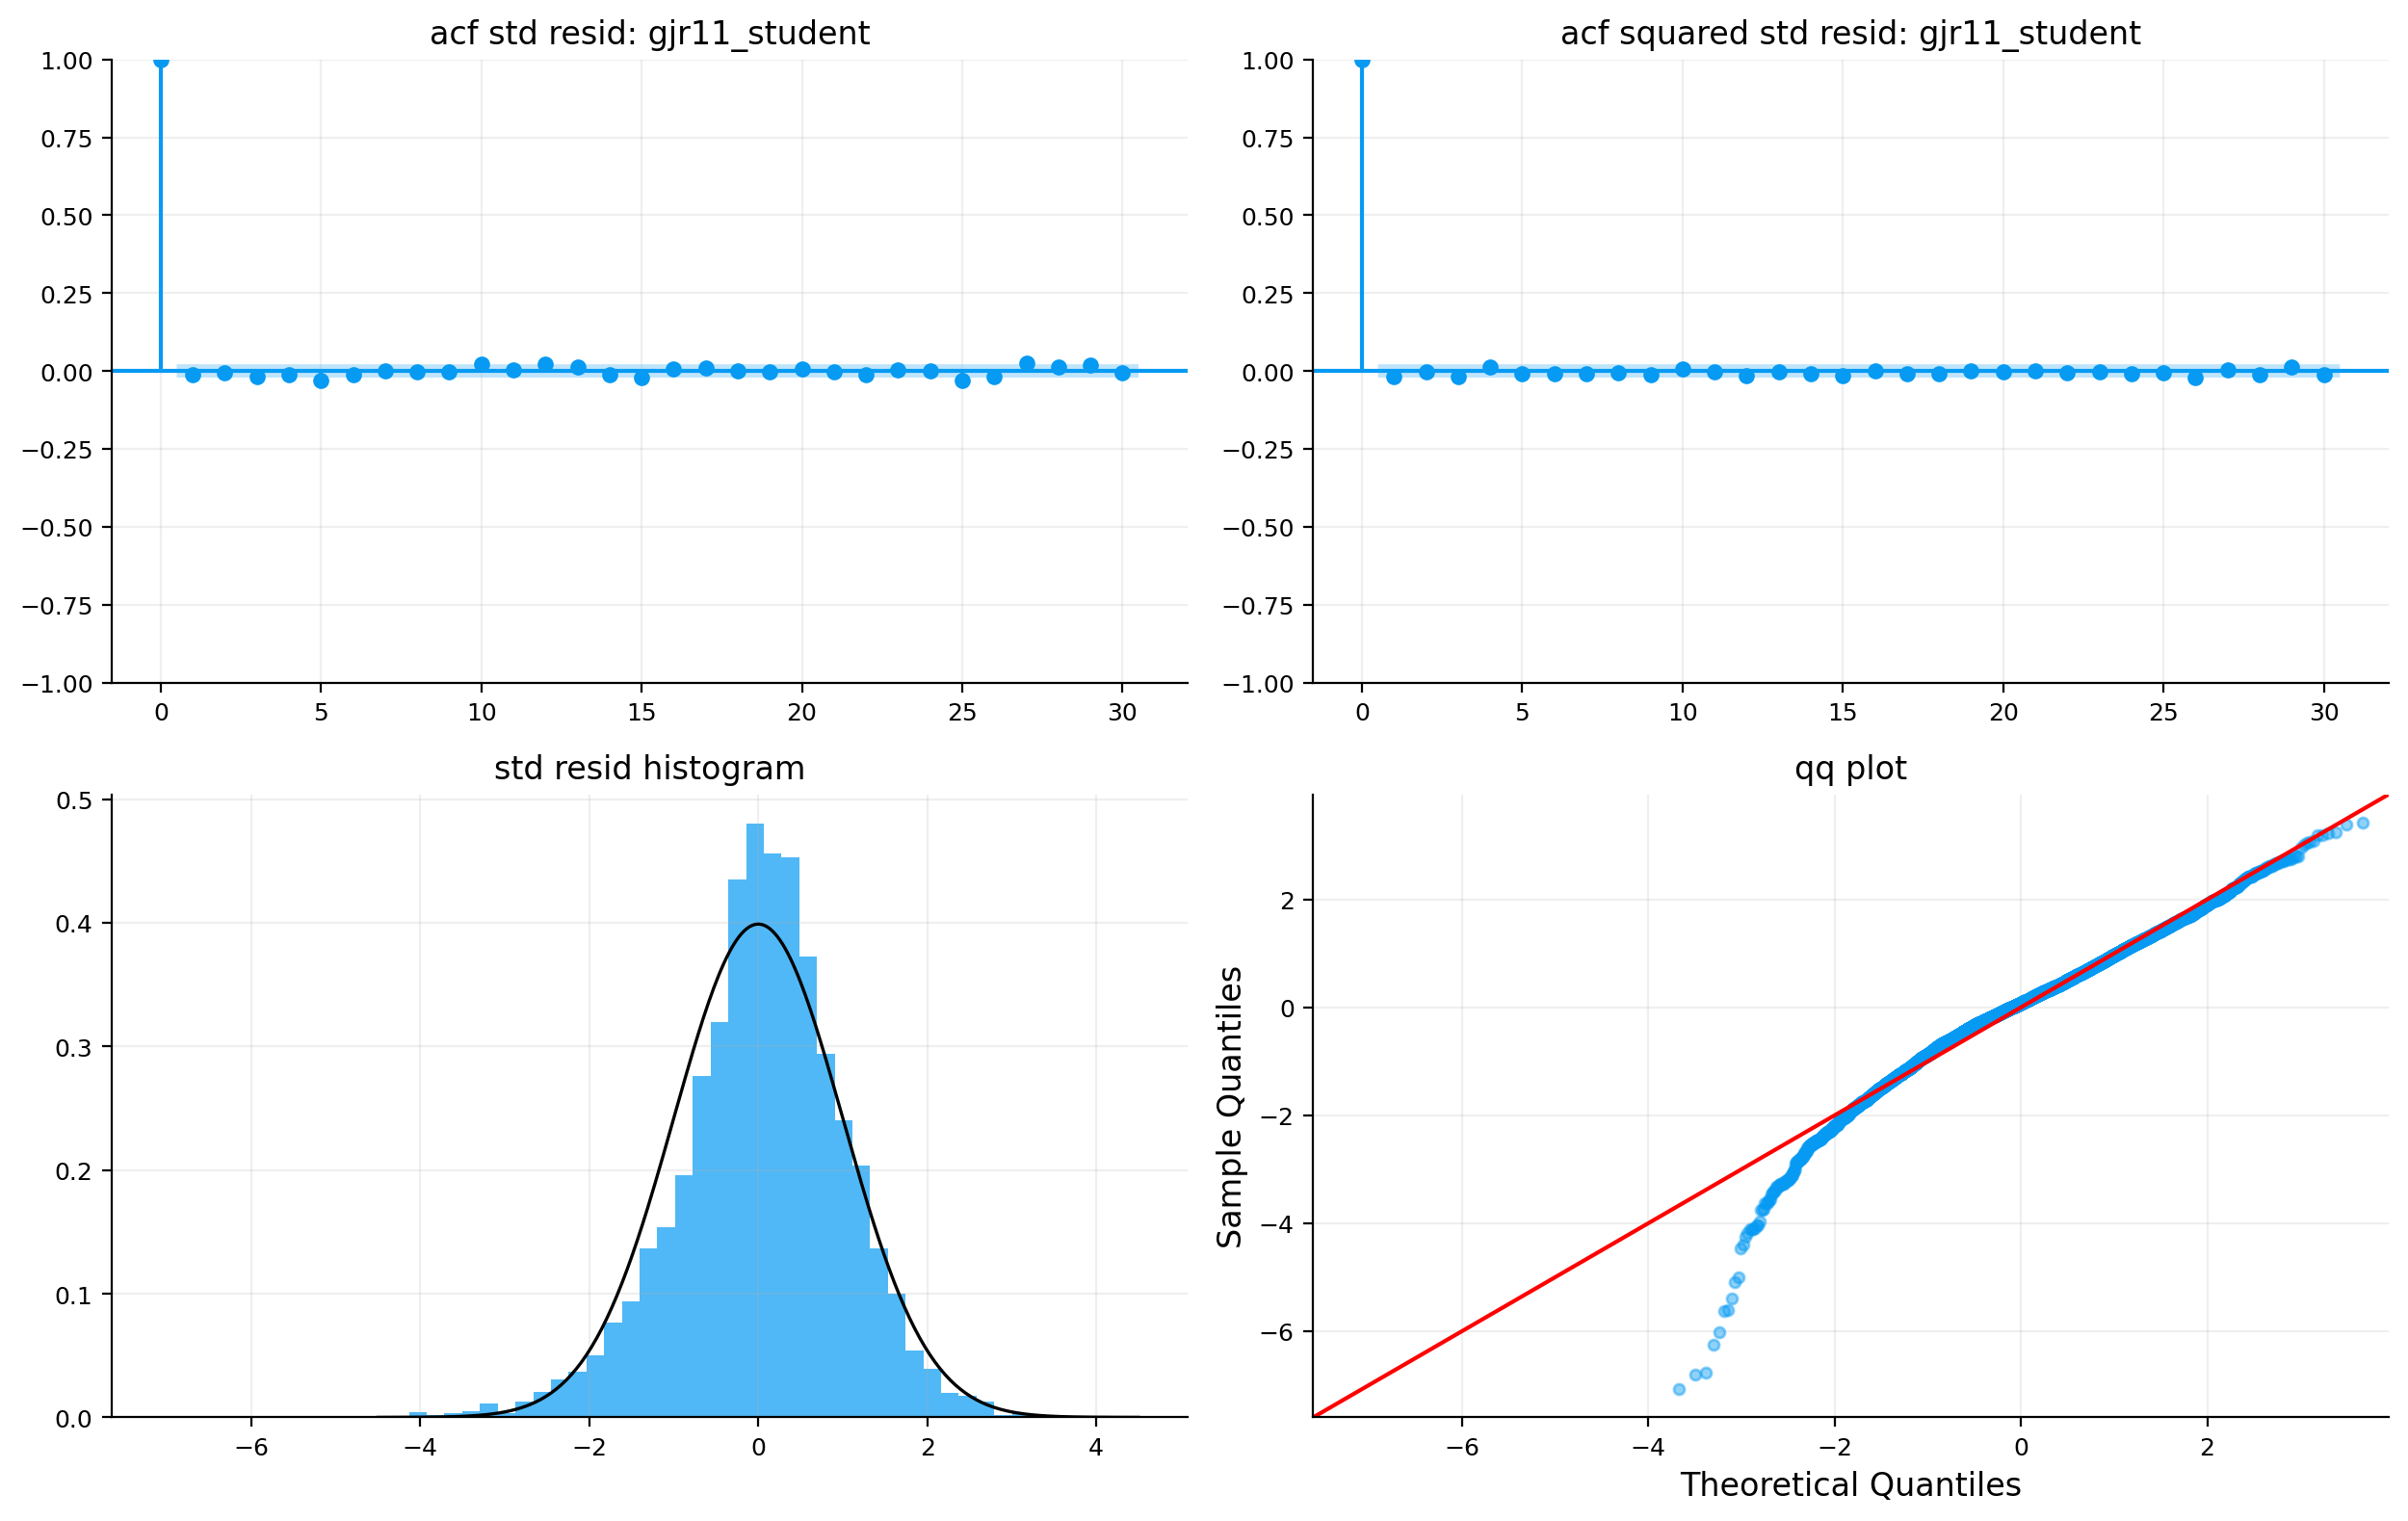

In [26]:
selected_models = [m for m in ["garch11_normal", "garch11_student", "egarch11_student", "figarch11_student"] if m in full_sample_fits]

fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.8), sharex=False)
axes = axes.ravel()

for ax, name in zip(axes, selected_models):
    res = full_sample_fits[name]["res"]
    cond_vol = np.asarray(res.conditional_volatility, dtype=float) / 100.0 * np.sqrt(252.0)
    ax.plot(returns_series["trade_date"], cond_vol, lw=1.1, label=name)
    ax.plot(df_market["trade_date"], df_market["rv_vol_fwd_21"], lw=0.9, alpha=0.8, label="future rv 21d")
    ax.set_title(name)
    ax.legend(loc="best")

for ax in axes[len(selected_models):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

best_aic_model = str(df_full_sample_fit.dropna(subset=["aic"]).iloc[0]["model"])
best_res = full_sample_fits[best_aic_model]["res"]
best_std_resid = pd.Series(best_res.std_resid).replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(2, 2, figsize=(12.6, 8.0))
plot_acf(best_std_resid, lags=30, ax=axes[0, 0], title=f"acf std resid: {best_aic_model}")
plot_acf(best_std_resid ** 2, lags=30, ax=axes[0, 1], title=f"acf squared std resid: {best_aic_model}")
axes[1, 0].hist(best_std_resid, bins=50, density=True, alpha=0.70)
x = np.linspace(-4.5, 4.5, 300)
axes[1, 0].plot(x, norm.pdf(x), c="black", lw=1.2)
axes[1, 0].set_title("std resid histogram")
qq = sm.ProbPlot(best_std_resid)
qq.qqplot(line="45", ax=axes[1, 1], alpha=0.45, markersize=4)
axes[1, 1].set_title("qq plot")
plt.tight_layout()
plt.show()


In [27]:
diag_rows = []
for name, entry in full_sample_fits.items():
    res = entry["res"]
    std_resid = pd.Series(res.std_resid).replace([np.inf, -np.inf], np.nan).dropna()
    if len(std_resid) < 40:
        continue
    lb_r = acorr_ljungbox(std_resid, lags=[10, 20], return_df=True)
    lb_s = acorr_ljungbox(std_resid ** 2, lags=[10, 20], return_df=True)
    arch_lm = het_arch(std_resid, nlags=10)
    params = res.params
    persistence = float(np.nansum([params.get(k, np.nan) for k in params.index if (k.startswith("alpha[") or k.startswith("beta[") or k.startswith("gamma["))]))
    beta1 = float(params.get("beta[1]", np.nan))
    alpha1 = float(params.get("alpha[1]", np.nan))
    if np.isfinite(alpha1) and np.isfinite(beta1) and (alpha1 + beta1 > 0) and (alpha1 + beta1 < 1):
        half_life = math.log(0.5) / math.log(alpha1 + beta1)
    else:
        half_life = np.nan
    diag_rows.append(
        {
            "model": name,
            "lb_resid_p_10": float(lb_r["lb_pvalue"].iloc[0]),
            "lb_resid_p_20": float(lb_r["lb_pvalue"].iloc[-1]),
            "lb_sq_p_10": float(lb_s["lb_pvalue"].iloc[0]),
            "lb_sq_p_20": float(lb_s["lb_pvalue"].iloc[-1]),
            "arch_lm_stat_10": float(arch_lm[0]),
            "arch_lm_p_10": float(arch_lm[1]),
            "persistence_like_sum": persistence,
            "half_life_days_garch11_style": half_life,
        }
    )

df_ts_diagnostics = pd.DataFrame(diag_rows).sort_values("lb_sq_p_20", ascending=False).reset_index(drop=True)
display(df_ts_diagnostics)


,model,lb_resid_p_10,lb_resid_p_20,lb_sq_p_10,lb_sq_p_20,arch_lm_stat_10,arch_lm_p_10,persistence_like_sum,half_life_days_garch11_style
0,gjr11_normal,0.043203,0.059126,0.530353,0.887720,8.798412,0.551336,1.068262,6.269144
1,garch22_normal,0.017040,0.019450,0.495926,0.744029,9.445253,0.490432,0.970723,0.459080
2,gjr11_student,0.048323,0.071475,0.371534,0.660261,10.852261,0.369144,1.089630,5.897189
3,figarch11_normal,0.022678,0.014626,0.120740,0.507961,15.206670,0.124707,0.000000,NaN
4,garch11_normal,0.014037,0.016231,0.144317,0.407774,14.457755,0.153117,0.984710,44.986966
5,garch11_student,0.013047,0.014613,0.190816,0.215952,13.504036,0.196839,0.995053,139.757699
6,figarch11_student,0.025716,0.016595,0.016712,0.131564,21.426392,0.018309,0.000000,NaN
7,garch22_student,0.018627,0.020197,0.072117,0.089389,17.021672,0.073886,0.991387,1.337092
8,egarch11_normal,0.010702,0.009200,0.000443,0.010370,30.563449,0.000692,1.193049,NaN
9,egarch11_student,0.010423,0.008864,0.000789,0.003833,29.336526,0.001099,1.195782,NaN


In [28]:
def rolling_garch_forecasts(
    returns_df,
    specs,
    horizons=(1, 5, 10, 21, 42, 63),
    initial_window=756,
    refit_every=21,
):
    ret = returns_df["spx_ret"].to_numpy(dtype=float)
    dates = returns_df["trade_date"].to_numpy()
    ret_pct = 100.0 * ret
    max_h = int(max(horizons))

    fit_cache = {}
    records = []
    last_fit_at = {spec["name"]: -10**9 for spec in specs}

    for t in range(initial_window, len(ret) - max_h - 1):
        train = ret_pct[: t + 1]

        for spec in specs:
            name = spec["name"]
            need_refit = (name not in fit_cache) or ((t - last_fit_at[name]) >= refit_every)

            if need_refit:
                try:
                    model, res = fit_arch_model(
                        returns_pct=train,
                        vol=spec["vol"],
                        p=spec["p"],
                        o=spec["o"],
                        q=spec["q"],
                        dist=spec["dist"],
                    )
                    fit_cache[name] = {"model": model, "res": res, "spec": spec}
                    last_fit_at[name] = t
                except Exception:
                    fit_cache[name] = None
                    last_fit_at[name] = t

            entry = fit_cache.get(name)
            if entry is None:
                continue

            try:
                try:
                    fc = entry["res"].forecast(horizon=max_h, reindex=False, method="analytic")
                except Exception:
                    fc = entry["res"].forecast(horizon=max_h, reindex=False, method="simulation", simulations=2000)
                fc_var_pct2 = np.asarray(fc.variance.values[-1], dtype=float)
                for h in horizons:
                    pred_var_sum = float(np.sum(fc_var_pct2[:h]) / (100.0 ** 2))
                    realized_var_sum = float(np.sum(ret[t + 1 : t + 1 + h] ** 2))
                    records.append(
                        {
                            "trade_date": pd.Timestamp(dates[t]),
                            "model": name,
                            "horizon": int(h),
                            "pred_var_sum": pred_var_sum,
                            "pred_vol_ann": np.sqrt(252.0 / h * pred_var_sum),
                            "realized_var_sum": realized_var_sum,
                            "realized_vol_ann": np.sqrt(252.0 / h * realized_var_sum),
                        }
                    )
            except Exception:
                continue

    return pd.DataFrame(records)

df_fc = rolling_garch_forecasts(
    returns_df=returns_series,
    specs=model_specs,
    horizons=rv_horizons,
    initial_window=756,
    refit_every=21)

display(df_fc.head())
display(df_fc.tail())


,trade_date,model,horizon,pred_var_sum,pred_vol_ann,realized_var_sum,realized_vol_ann
0,1996-01-26,garch11_normal,1,0.000040,0.100579,0.000017,0.066258
1,1996-01-26,garch11_normal,5,0.000198,0.099910,0.000224,0.106338
2,1996-01-26,garch11_normal,10,0.000390,0.099142,0.000478,0.109795
3,1996-01-26,garch11_normal,21,0.000795,0.097684,0.001397,0.129484
4,1996-01-26,garch11_normal,42,0.001523,0.095591,0.003193,0.138420


,trade_date,model,horizon,pred_var_sum,pred_vol_ann,realized_var_sum,realized_vol_ann
449935,2025-11-12,figarch11_student,5,0.000412,0.144018,0.000446,0.150010
449936,2025-11-12,figarch11_student,10,0.000839,0.145443,0.001153,0.170423
449937,2025-11-12,figarch11_student,21,0.001842,0.148673,0.001407,0.129927
449938,2025-11-12,figarch11_student,42,0.003947,0.153885,0.002002,0.109589
449939,2025-11-12,figarch11_student,63,0.006251,0.158120,0.003608,0.120138


In [29]:
def qlike_loss(realized_var, forecast_var):
    realized_var = np.asarray(realized_var, dtype=float)
    forecast_var = np.asarray(forecast_var, dtype=float)
    mask = np.isfinite(realized_var) & np.isfinite(forecast_var) & (realized_var > 0) & (forecast_var > 0)
    if mask.sum() == 0:
        return np.nan
    rv = realized_var[mask]
    fv = forecast_var[mask]
    return float(np.mean(np.log(fv) + rv / fv))

def mz_regression(y, x):
    z = pd.DataFrame({"y": y, "x": x}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(z) < 25:
        return {"alpha": np.nan, "beta": np.nan, "r2": np.nan, "alpha_p": np.nan, "beta_p": np.nan}
    X = sm.add_constant(z["x"])
    res = sm.OLS(z["y"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    return {
        "alpha": float(res.params.get("const", np.nan)),
        "beta": float(res.params.get("x", np.nan)),
        "r2": float(res.rsquared),
        "alpha_p": float(res.pvalues.get("const", np.nan)),
        "beta_p": float(res.pvalues.get("x", np.nan)),
    }

def dm_test(loss_a, loss_b, h=1):
    d = pd.Series(np.asarray(loss_a, dtype=float) - np.asarray(loss_b, dtype=float)).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    n = len(d)
    if n < max(20, h + 5):
        return {"dm_stat": np.nan, "dm_pvalue": np.nan, "n": n}
    mean_d = float(np.mean(d))
    gamma0 = float(np.var(d, ddof=1))
    long_run = gamma0
    max_lag = int(max(1, h - 1))
    for lag in range(1, max_lag + 1):
        cov = np.cov(d[lag:], d[:-lag], ddof=1)[0, 1]
        long_run += 2.0 * (1.0 - lag / (max_lag + 1.0)) * cov
    if long_run <= 0 or not np.isfinite(long_run):
        return {"dm_stat": np.nan, "dm_pvalue": np.nan, "n": n}
    dm = mean_d / math.sqrt(long_run / n)
    p = 2.0 * (1.0 - norm.cdf(abs(dm)))
    return {"dm_stat": float(dm), "dm_pvalue": float(p), "n": int(n)}

score_rows = []
for (name, h), g in df_fc.groupby(["model", "horizon"]):
    mse_var = float(np.mean((g["pred_var_sum"] - g["realized_var_sum"]) ** 2))
    rmse_var = float(np.sqrt(mse_var))
    mae_var = float(np.mean(np.abs(g["pred_var_sum"] - g["realized_var_sum"])))
    mse_vol = float(np.mean((g["pred_vol_ann"] - g["realized_vol_ann"]) ** 2))
    rmse_vol = float(np.sqrt(mse_vol))
    mae_vol = float(np.mean(np.abs(g["pred_vol_ann"] - g["realized_vol_ann"])))
    corr = float(g[["pred_vol_ann", "realized_vol_ann"]].corr().iloc[0, 1]) if len(g) >= 2 else np.nan
    mz = mz_regression(g["realized_vol_ann"], g["pred_vol_ann"])
    score_rows.append(
        {
            "model": name,
            "horizon": int(h),
            "qlike_var": qlike_loss(g["realized_var_sum"], g["pred_var_sum"]),
            "rmse_var": rmse_var,
            "mae_var": mae_var,
            "rmse_vol": rmse_vol,
            "mae_vol": mae_vol,
            "corr_vol": corr,
            "mz_alpha": mz["alpha"],
            "mz_beta": mz["beta"],
            "mz_r2": mz["r2"],
            "mz_alpha_p": mz["alpha_p"],
            "mz_beta_p": mz["beta_p"],
            "n_obs": int(len(g)),
        }
    )

df_scores = pd.DataFrame(score_rows).sort_values(["horizon", "qlike_var", "rmse_vol"]).reset_index(drop=True)

ranked = df_scores.copy()
for metric in ["qlike_var", "rmse_var", "mae_var", "rmse_vol", "mae_vol"]:
    ranked[f"rank_{metric}"] = ranked.groupby("horizon")[metric].rank(method="average", ascending=True)
ranked["rank_mean"] = ranked[[c for c in ranked.columns if c.startswith("rank_")]].mean(axis=1)

df_model_ranks = (
    ranked.groupby("model", as_index=False)["rank_mean"]
    .mean()
    .sort_values("rank_mean", ascending=True)
    .reset_index(drop=True)
)

best_model_name = str(df_model_ranks.iloc[0]["model"])
display(df_model_ranks)
display(df_scores[df_scores["horizon"] == 21].sort_values(["qlike_var", "rmse_vol"]).reset_index(drop=True))

dm_rows = []
for h in rv_horizons:
    g = df_fc[df_fc["horizon"] == h].copy()
    if best_model_name not in g["model"].unique():
        continue
    best = g[g["model"] == best_model_name].sort_values("trade_date")
    for competitor in sorted(set(g["model"]) - {best_model_name}):
        other = g[g["model"] == competitor].sort_values("trade_date")
        joined = best[["trade_date", "pred_var_sum", "realized_var_sum"]].merge(
            other[["trade_date", "pred_var_sum"]],
            on="trade_date",
            how="inner",
            suffixes=("_best", "_other"),
        )
        if len(joined) == 0:
            continue
        loss_best = np.log(joined["pred_var_sum_best"]) + joined["realized_var_sum"] / joined["pred_var_sum_best"]
        loss_other = np.log(joined["pred_var_sum_other"]) + joined["realized_var_sum"] / joined["pred_var_sum_other"]
        dm = dm_test(loss_best, loss_other, h=h)
        dm_rows.append({"horizon": h, "best_model": best_model_name, "competitor": competitor, **dm})

df_dm = pd.DataFrame(dm_rows).sort_values(["horizon", "dm_pvalue"]).reset_index(drop=True)
display(df_dm.head(20))


,model,rank_mean
0,gjr11_normal,1.566667
1,egarch11_normal,2.233333
2,gjr11_student,3.833333
3,egarch11_student,4.300000
4,figarch11_normal,5.566667
5,garch22_normal,5.733333
6,figarch11_student,6.233333
7,garch11_normal,6.833333
8,garch22_student,9.100000
9,garch11_student,9.600000


,model,horizon,qlike_var,rmse_var,mae_var,rmse_vol,mae_vol,corr_vol,mz_alpha,mz_beta,mz_r2,mz_alpha_p,mz_beta_p,n_obs
0,egarch11_normal,21,-4.971335,0.005348,0.002025,0.085441,0.054714,0.560184,0.032821,0.757543,0.313806,0.000102,0.000000,7499
1,egarch11_student,21,-4.953560,0.005558,0.002062,0.087442,0.054571,0.554075,0.045413,0.689934,0.306999,0.000000,0.000000,7499
2,garch22_normal,21,-4.947880,0.005696,0.002114,0.089314,0.055359,0.556165,0.053576,0.641233,0.309319,0.000000,0.000000,7499
3,gjr11_normal,21,-4.946988,0.005512,0.002001,0.086216,0.053481,0.581187,0.047833,0.681704,0.337778,0.000000,0.000000,7499
4,garch11_normal,21,-4.946364,0.005724,0.002123,0.089527,0.055428,0.555303,0.054045,0.637873,0.308362,0.000000,0.000000,7499
5,gjr11_student,21,-4.945688,0.005706,0.002089,0.088530,0.054820,0.579289,0.053266,0.638809,0.335576,0.000000,0.000000,7499
6,garch22_student,21,-4.944329,0.005945,0.002203,0.091782,0.056593,0.552556,0.058712,0.602594,0.305318,0.000000,0.000000,7499
7,figarch11_normal,21,-4.942100,0.005511,0.002105,0.088669,0.056373,0.546517,0.044167,0.679546,0.298681,0.000001,0.000000,7499
8,figarch11_student,21,-4.940826,0.005538,0.002100,0.088754,0.055828,0.548572,0.046514,0.670420,0.300931,0.000000,0.000000,7499
9,garch11_student,21,-4.940106,0.005959,0.002205,0.091827,0.056513,0.551374,0.058961,0.602052,0.304013,0.000000,0.000000,7499


,horizon,best_model,competitor,dm_stat,dm_pvalue,n
0,1,gjr11_normal,garch22_student,-2.888582,0.003870,7499
1,1,gjr11_normal,garch22_normal,-2.533079,0.011307,7499
2,1,gjr11_normal,figarch11_student,-1.960837,0.049898,7499
3,1,gjr11_normal,garch11_student,-1.951084,0.051047,7499
4,1,gjr11_normal,egarch11_student,-1.496472,0.134531,7499
5,1,gjr11_normal,figarch11_normal,-1.484537,0.137667,7499
6,1,gjr11_normal,garch11_normal,-1.478377,0.139307,7499
7,1,gjr11_normal,egarch11_normal,-1.050735,0.293381,7499
8,1,gjr11_normal,gjr11_student,-0.631396,0.527782,7499
9,5,gjr11_normal,garch22_student,-1.686451,0.091709,7499


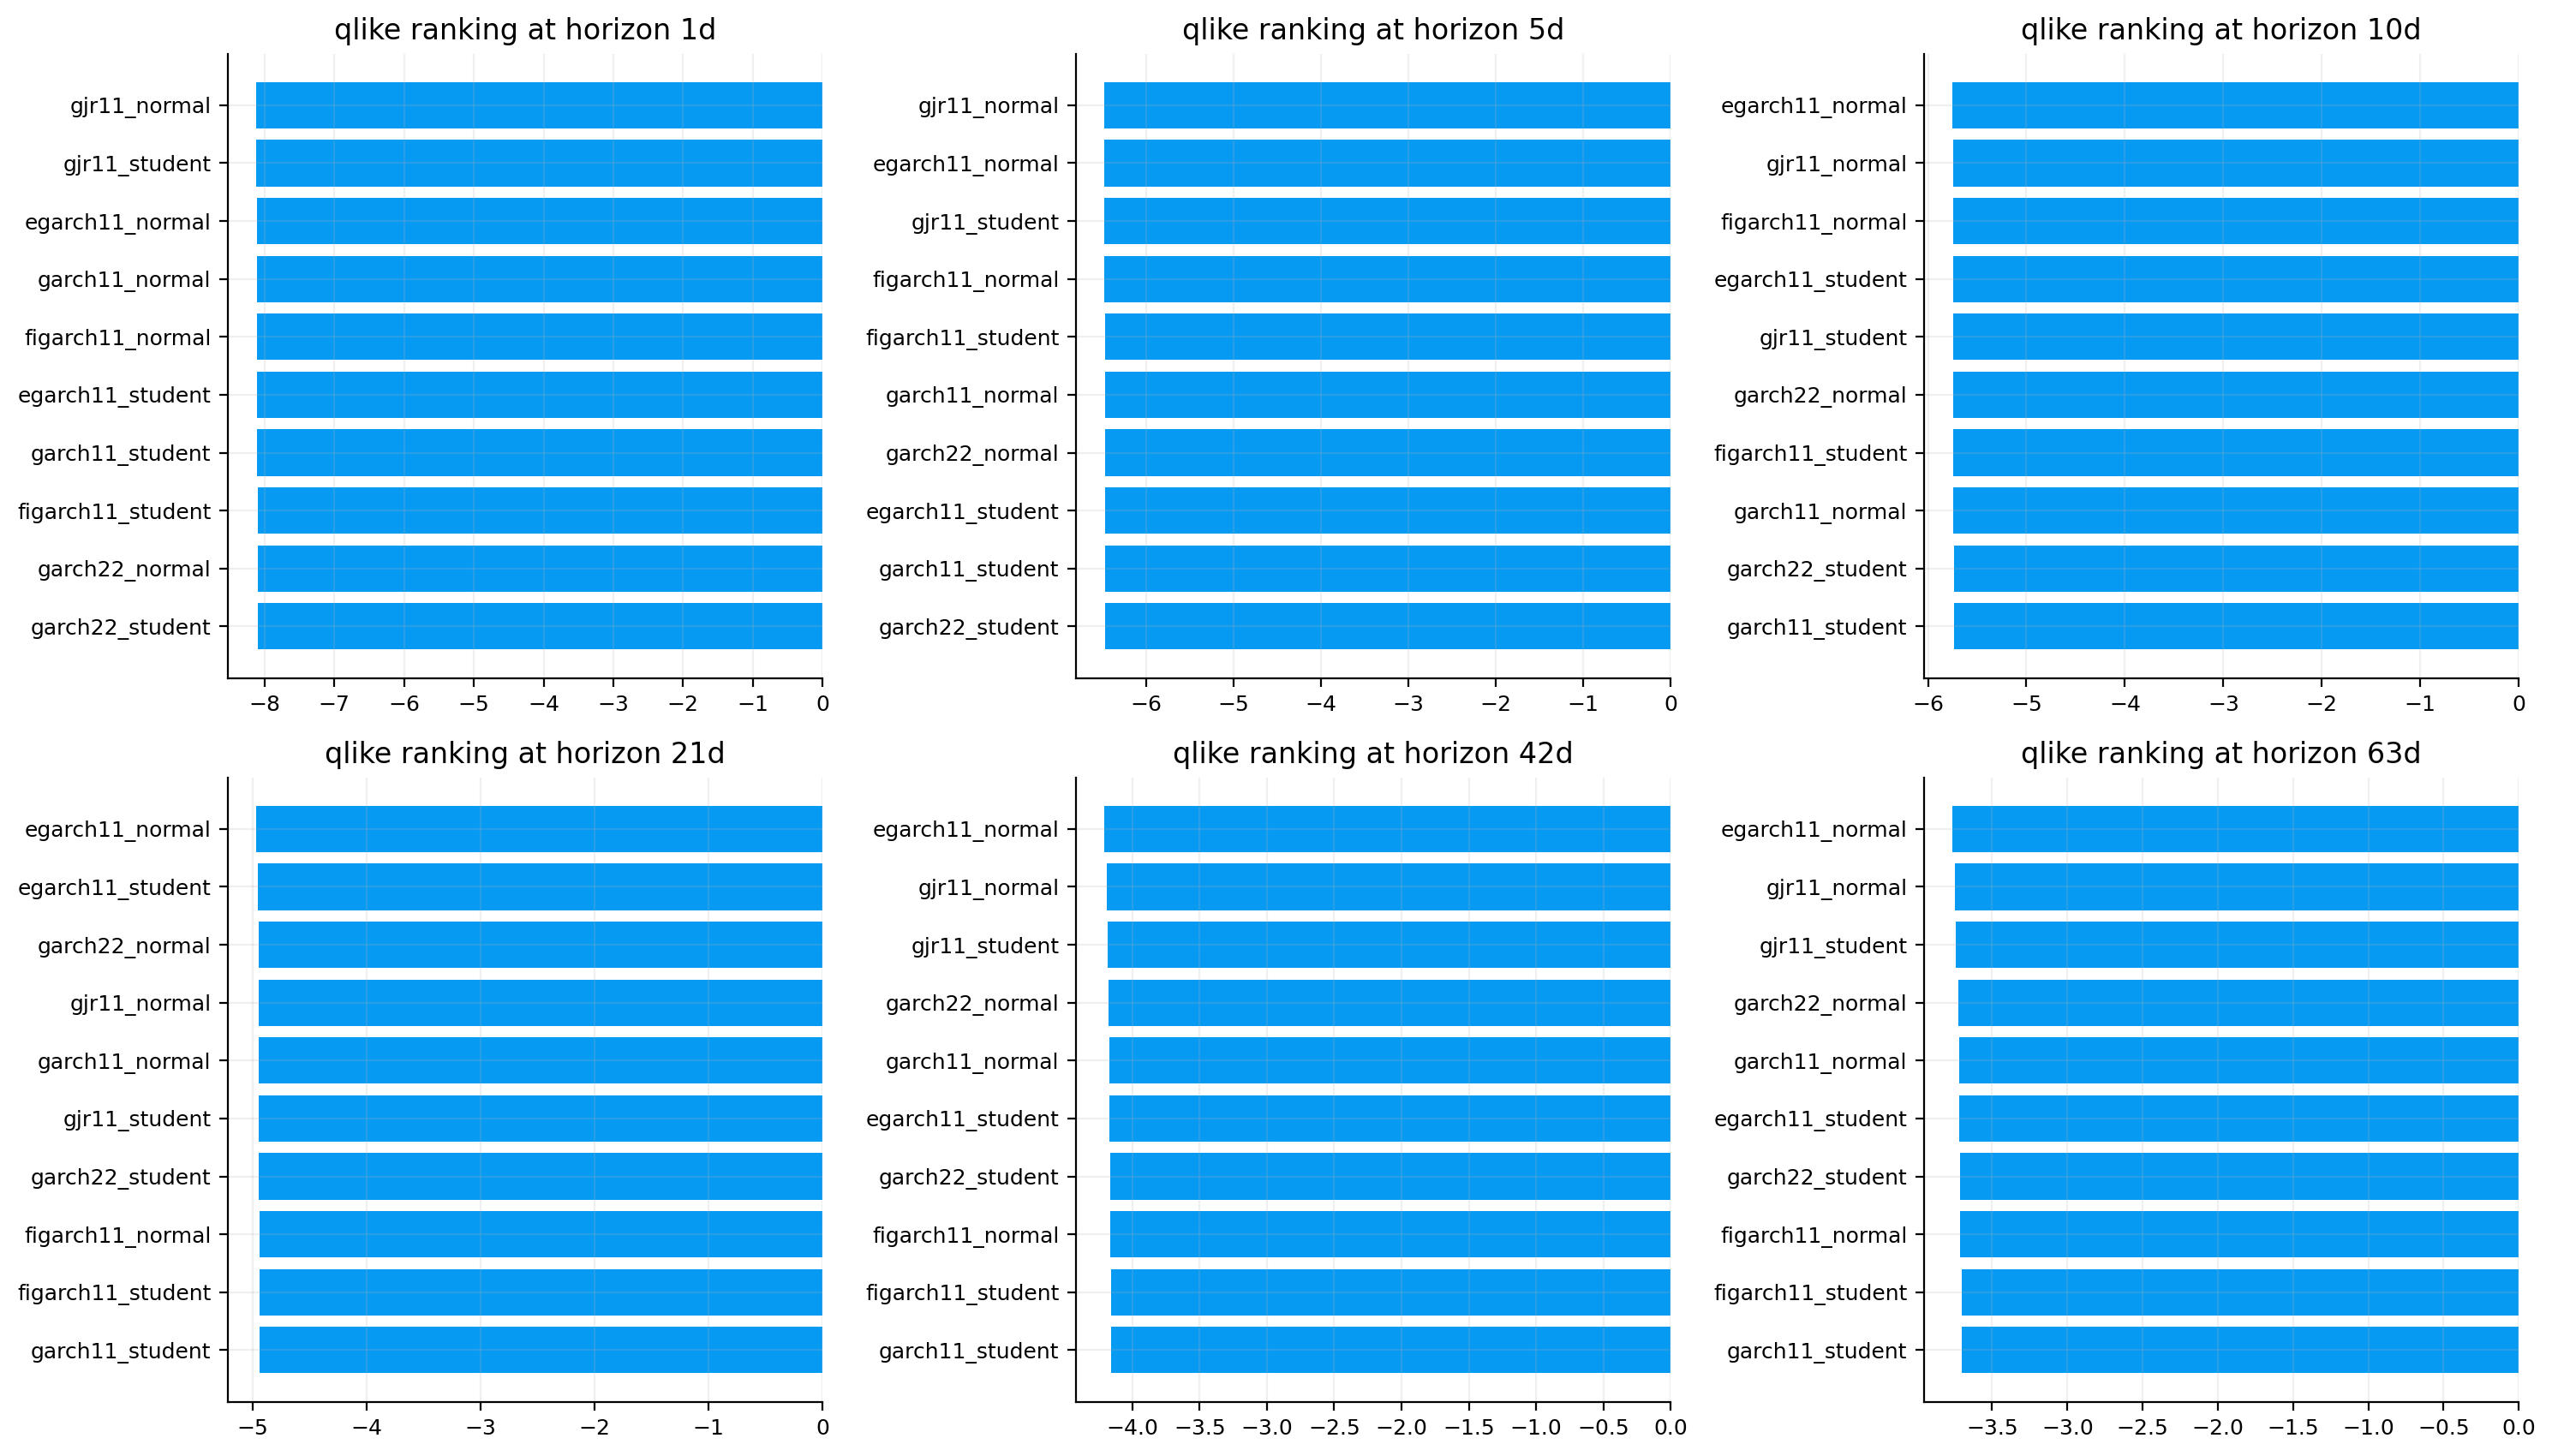

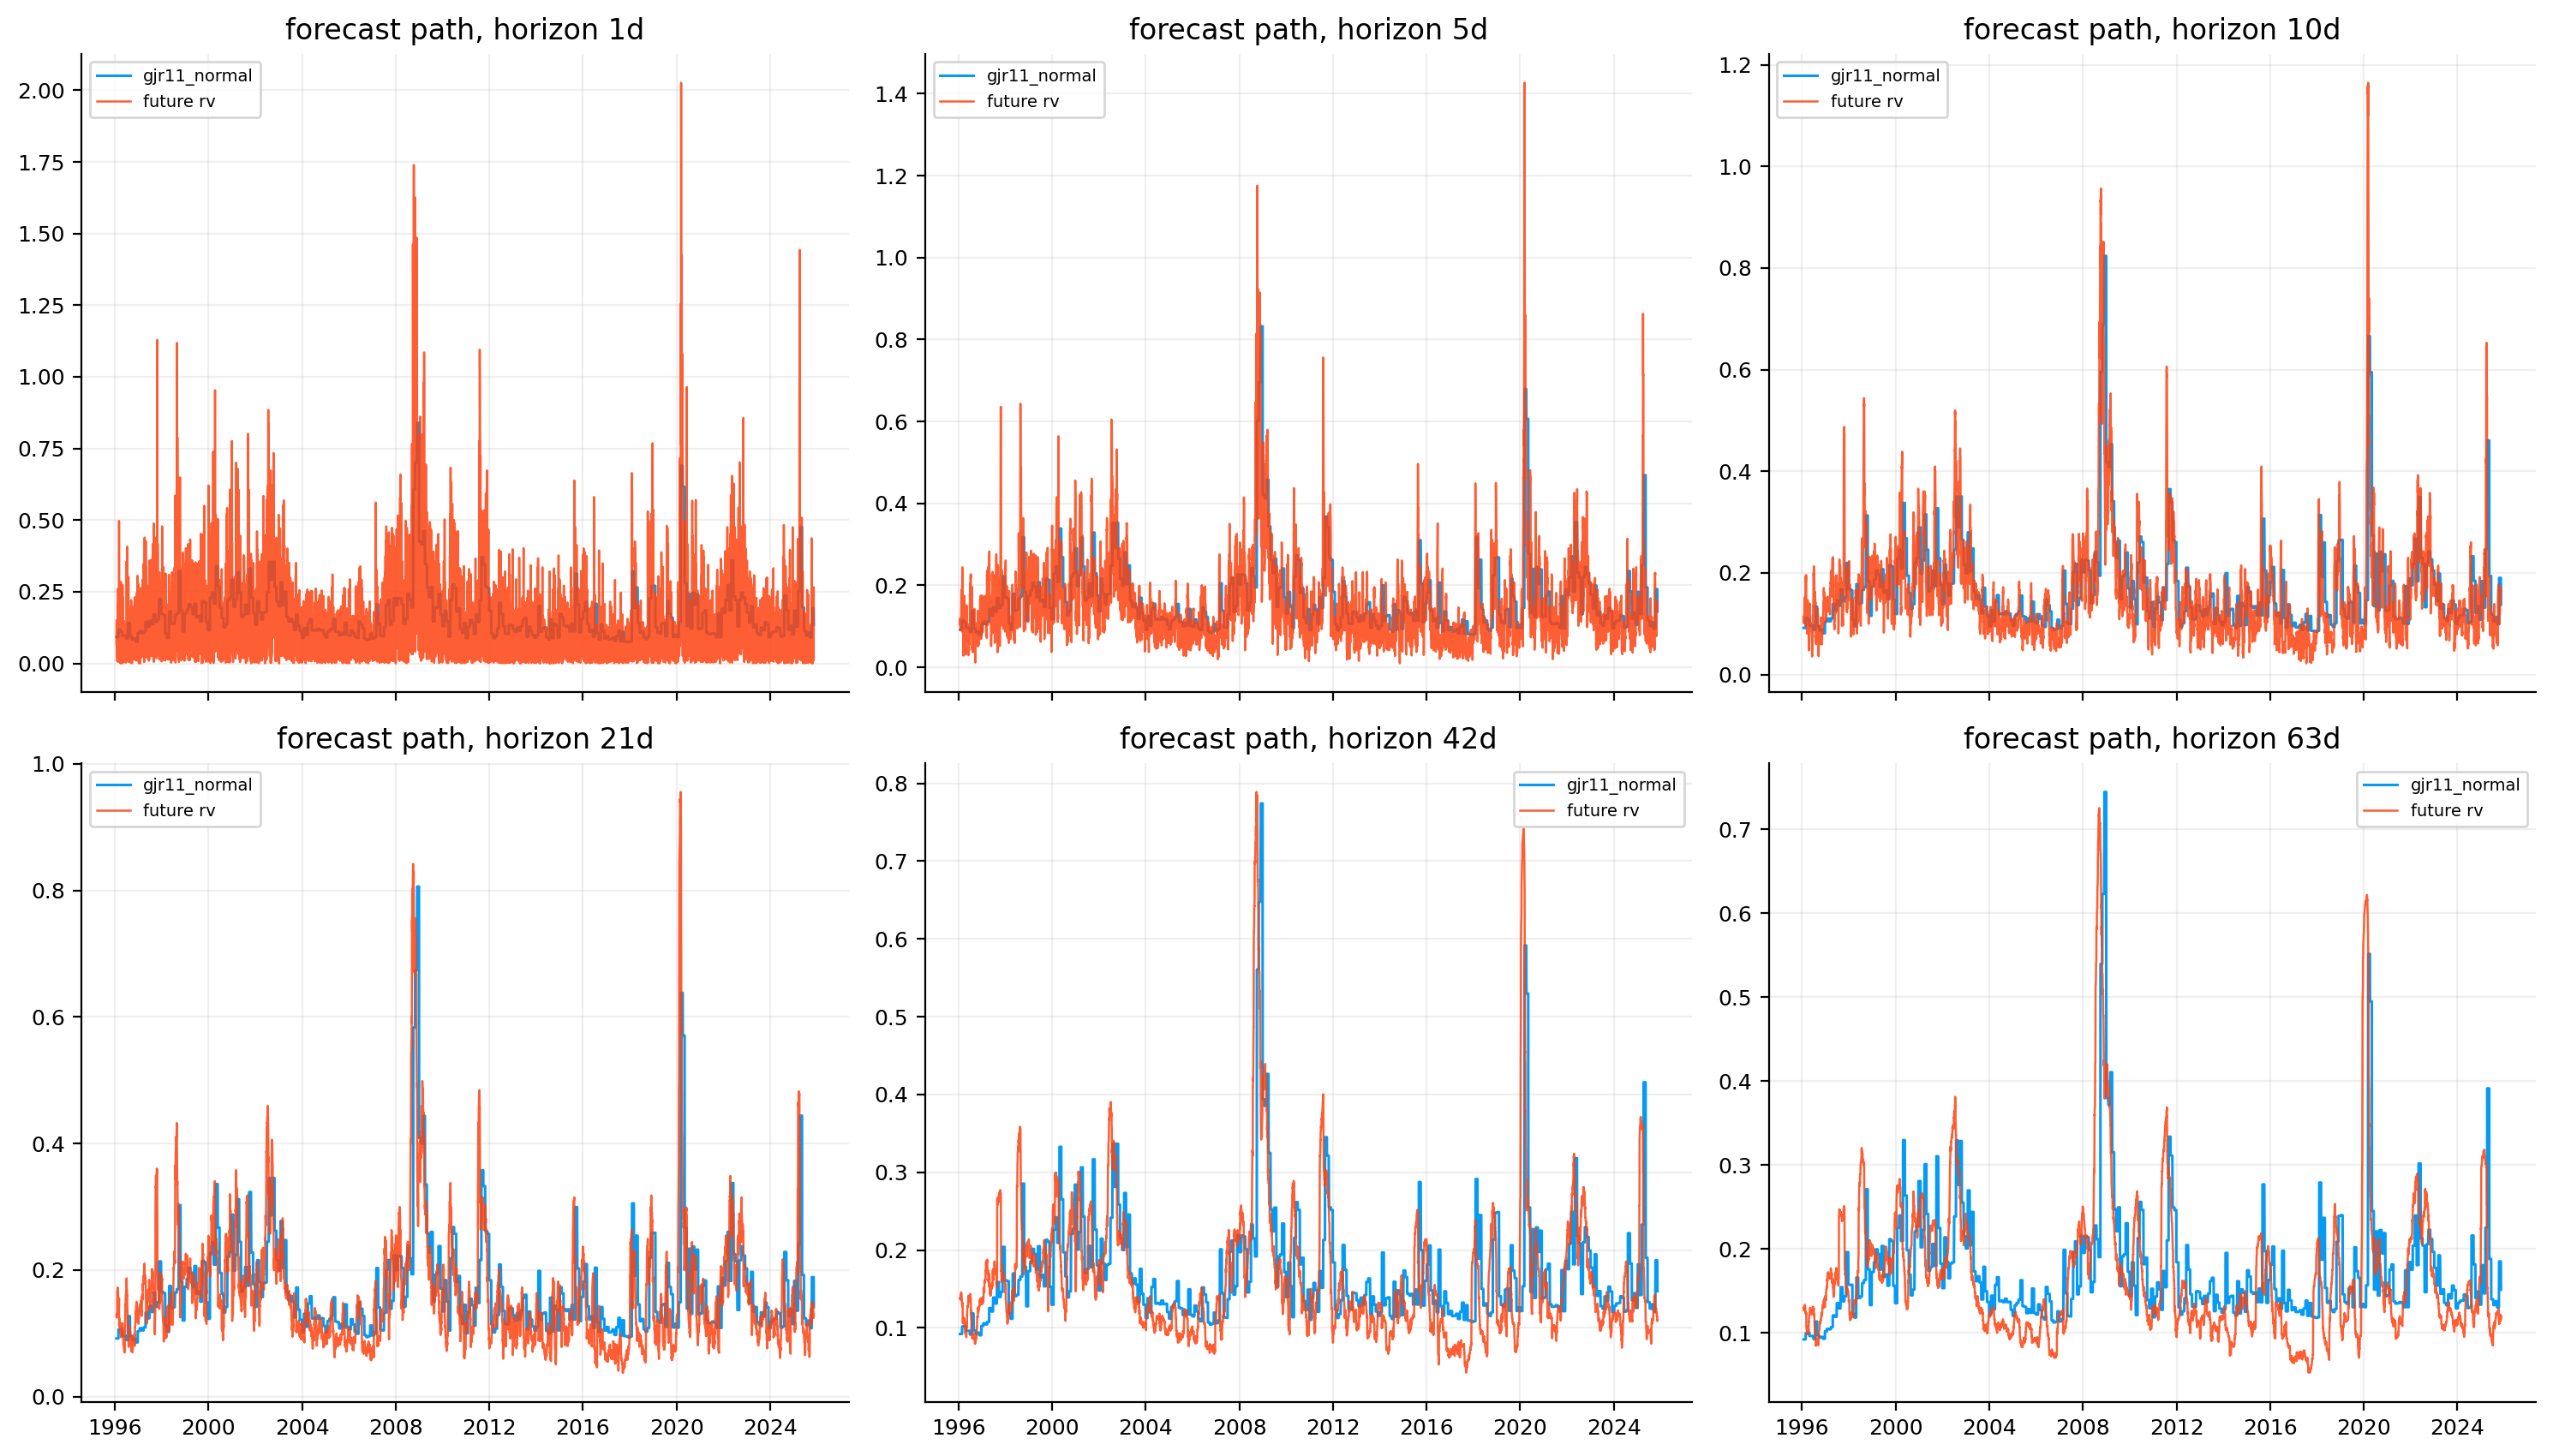

horizon,trade_date,garch_vol_ann_1,garch_vol_ann_5,garch_vol_ann_10,garch_vol_ann_21,garch_vol_ann_42,garch_vol_ann_63
0,1996-01-26,0.091574,0.091690,0.091800,0.091955,0.092091,0.092149
1,1996-01-29,0.091574,0.091690,0.091800,0.091955,0.092091,0.092149
2,1996-01-30,0.091574,0.091690,0.091800,0.091955,0.092091,0.092149
3,1996-01-31,0.091574,0.091690,0.091800,0.091955,0.092091,0.092149
4,1996-02-01,0.091574,0.091690,0.091800,0.091955,0.092091,0.092149


In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15.0, 8.6))
axes = axes.ravel()

for ax, h in zip(axes, rv_horizons):
    pivot = df_scores[df_scores["horizon"] == h].sort_values(["qlike_var", "rmse_vol"])
    ax.barh(pivot["model"], pivot["qlike_var"])
    ax.set_title(f"qlike ranking at horizon {h}d")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15.0, 8.6), sharex=True)
axes = axes.ravel()

for ax, h in zip(axes, rv_horizons):
    g = df_fc[(df_fc["horizon"] == h) & (df_fc["model"] == best_model_name)].copy()
    ax.plot(g["trade_date"], g["pred_vol_ann"], lw=1.1, label=f"{best_model_name}")
    ax.plot(g["trade_date"], g["realized_vol_ann"], lw=0.9, alpha=0.85, label="future rv")
    ax.set_title(f"forecast path, horizon {h}d")
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

forecast_wide = (
    df_fc[df_fc["model"] == best_model_name]
    .pivot(index="trade_date", columns="horizon", values="pred_vol_ann")
    .rename(columns=lambda x: f"garch_vol_ann_{int(x)}")
    .reset_index()
)
display(forecast_wide.head())


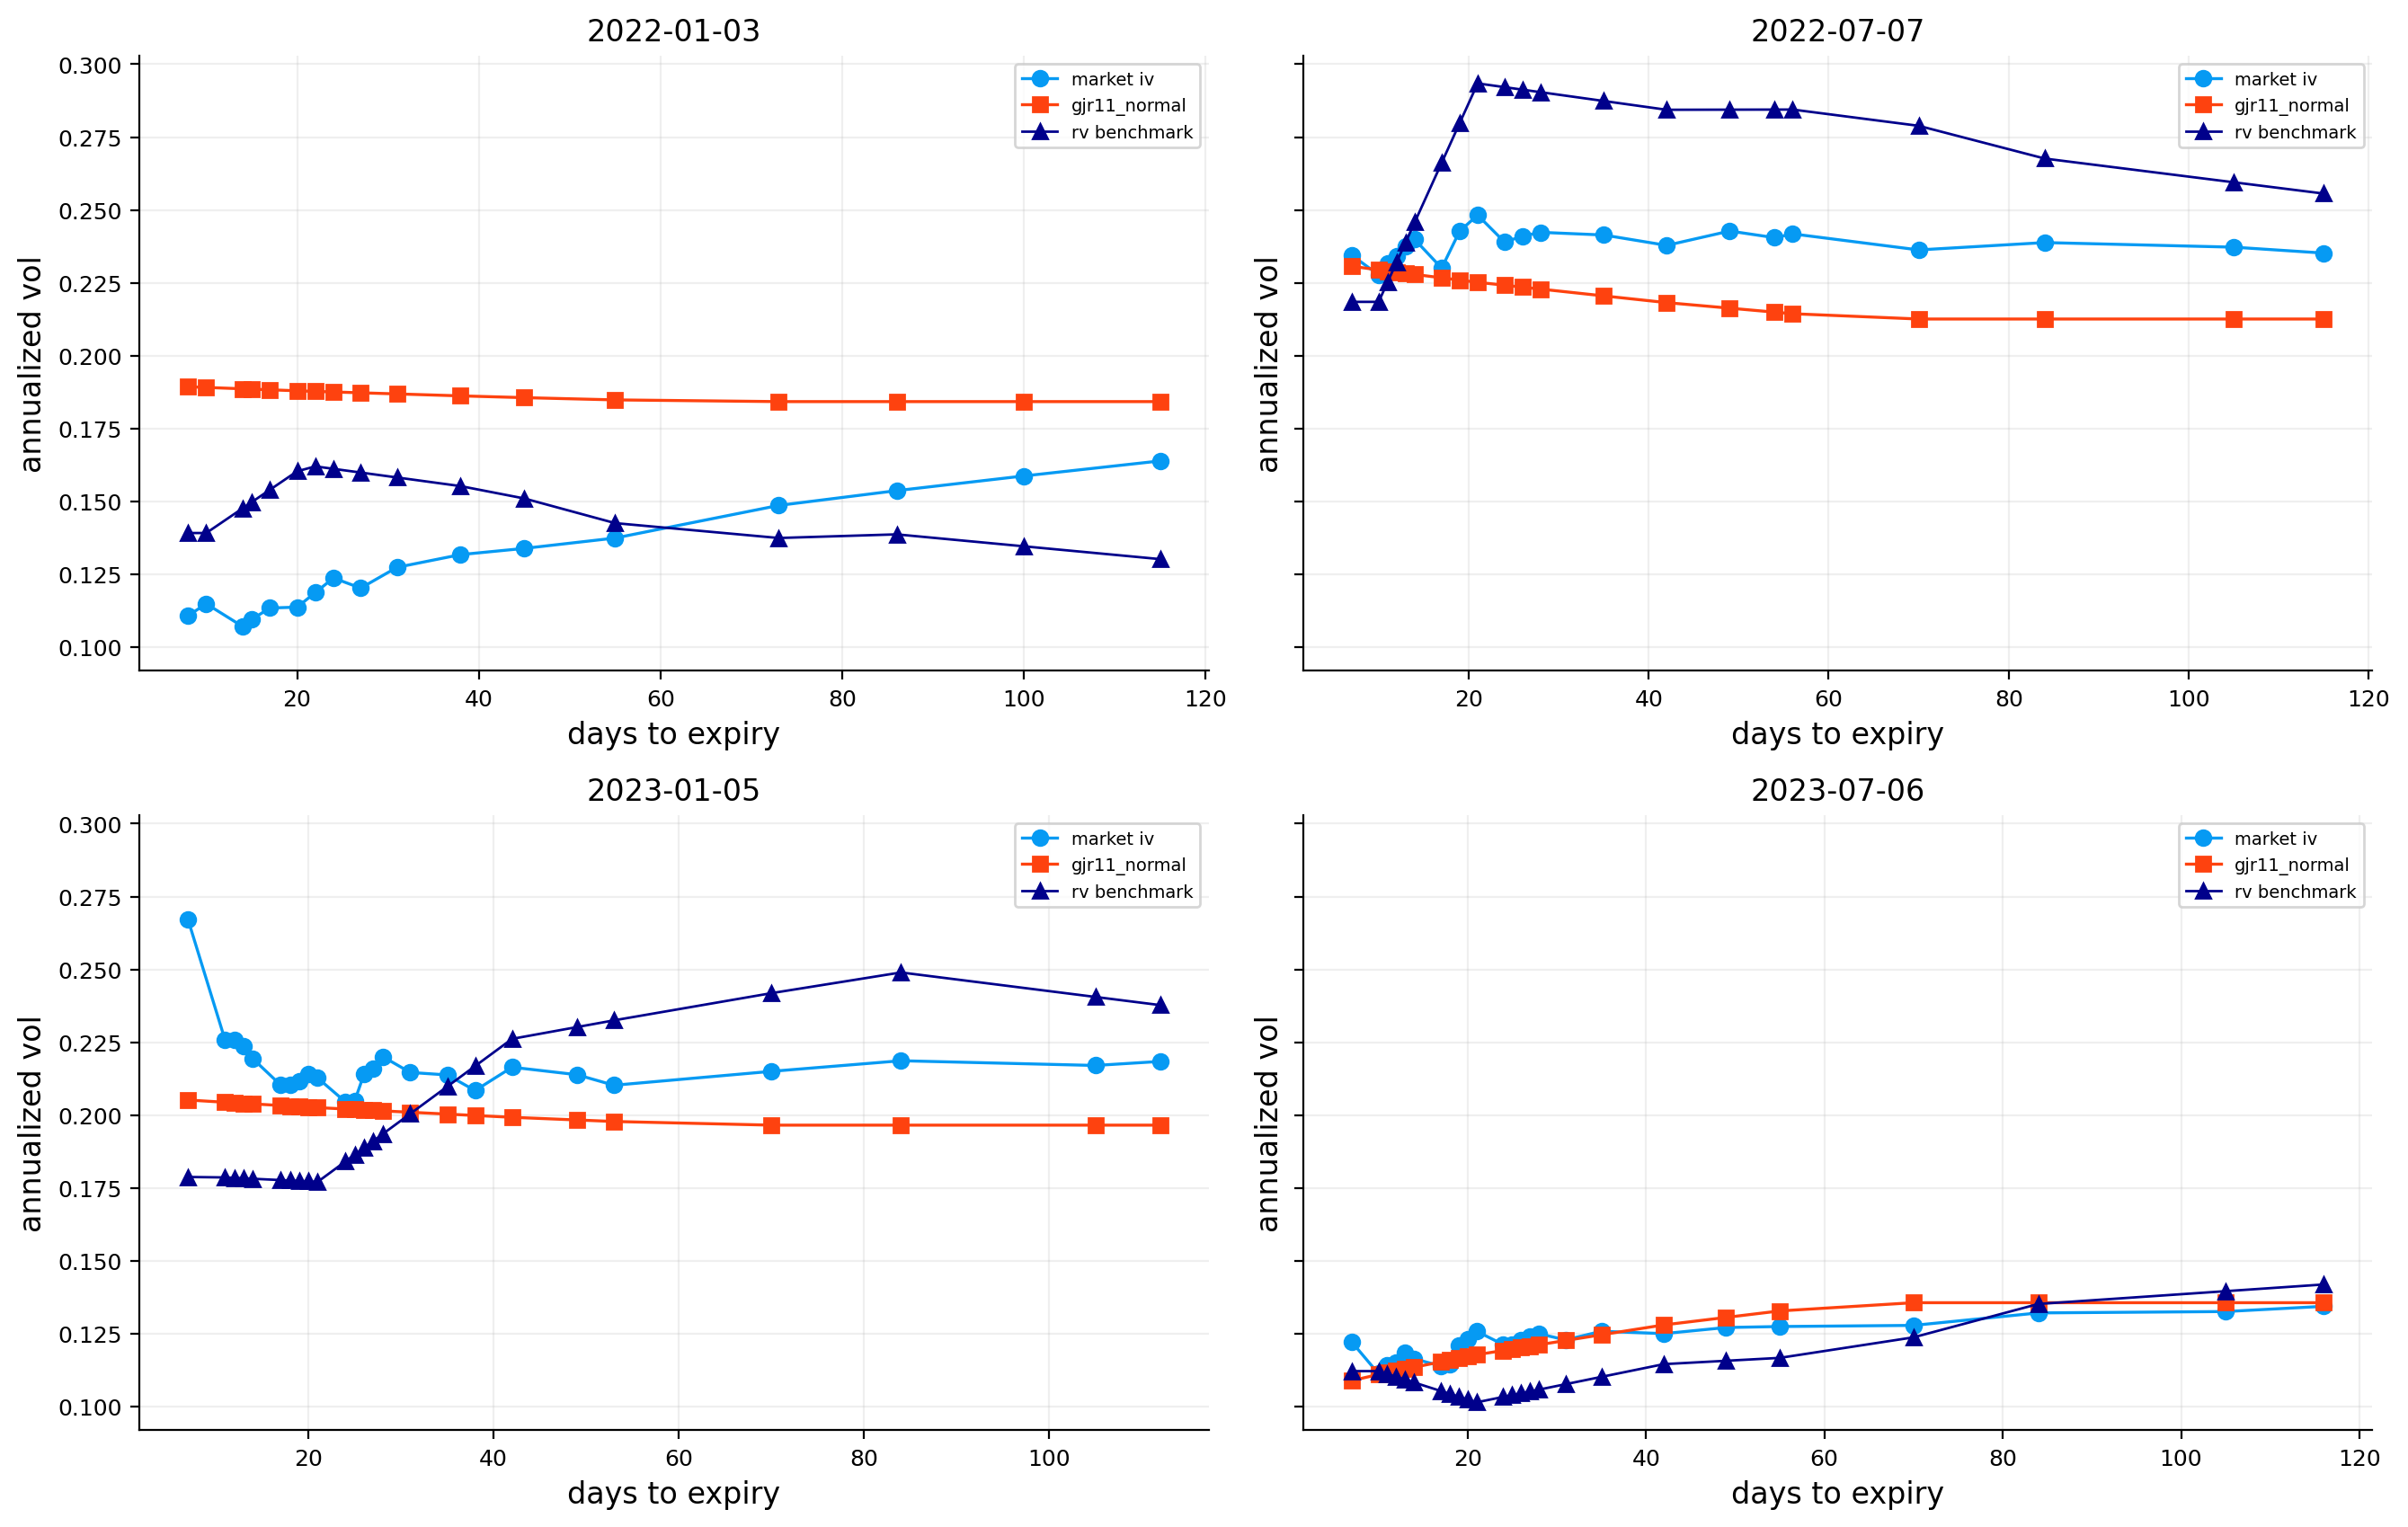

,trade_date,expiry_datetime,tau,tau_days,spot,forward,rate,q,market_iv,garch_iv,rv_iv,n_quotes,rv_vol_fwd_21,rv_vol_fwd_42,rv_vol_fwd_63,iv_minus_garch,iv_minus_rv
0,2022-01-03,2022-01-12,0.022815,8,"4,795.570000","4,794.250106",0.000500,0.012565,0.110748,0.189333,0.139128,4,0.185920,0.206689,0.212171,-0.078584,-0.028380
1,2022-01-03,2022-01-14,0.028291,10,"4,795.570000","4,794.099634",0.000500,0.011339,0.114848,0.189085,0.139128,4,0.185920,0.206689,0.212171,-0.074238,-0.024280
2,2022-01-03,2022-01-18,0.039243,14,"4,795.570000","4,794.050472",0.000500,0.008576,0.107059,0.188627,0.147600,4,0.185920,0.206689,0.212171,-0.081567,-0.040540
3,2022-01-03,2022-01-19,0.041980,15,"4,795.570000","4,793.999244",0.000500,0.008304,0.109465,0.188512,0.149718,4,0.185920,0.206689,0.212171,-0.079047,-0.040252
4,2022-01-03,2022-01-21,0.047456,17,"4,795.570000","4,794.099030",0.000500,0.006965,0.113394,0.188283,0.153953,4,0.185920,0.206689,0.212171,-0.074889,-0.040559


In [31]:
horizon_grid = np.array(rv_horizons, dtype=float)
forecast_col_map = {h: f"garch_vol_ann_{int(h)}" for h in rv_horizons}
df_options = df_options.merge(forecast_wide, on="trade_date", how="left")

def interp_curve_from_row(row, prefix_map, horizons, tau_days):
    vals = np.array([row.get(prefix_map[h], np.nan) for h in horizons], dtype=float)
    mask = np.isfinite(vals)
    if mask.sum() == 0:
        return np.nan
    if mask.sum() == 1:
        return float(vals[mask][0])
    x = np.array(horizons, dtype=float)[mask]
    y = vals[mask]
    t = float(np.clip(tau_days, x.min(), x.max()))
    return float(np.interp(t, x, y))

df_options["sigma_garch"] = [
    interp_curve_from_row(row, forecast_col_map, rv_horizons, float(row["dte_days"]))
    for _, row in df_options.iterrows()
]
df_options["sigma_rv"] = df_options["realized_vol"]
df_options["sigma_iv"] = df_options["iv_mid"]

rate_imp, div_imp, carry_disc = implied_rate_dividend(
    df_options["s"].values,
    df_options["df"].values,
    df_options["f_hat"].values,
    df_options["tau"].values,
)
df_options["rate_imp"] = rate_imp
df_options["div_imp"] = div_imp
df_options["carry_disc"] = carry_disc

atm_panel = df_options[df_options["iv_ok"]].copy()
atm_panel["weight"] = np.sqrt(np.clip(atm_panel["volume"].fillna(0.0), 0.0, None) + 1.0) / np.clip(atm_panel["spread"], 1e-4, None)
atm_panel["atm_dist_f"] = np.abs(atm_panel["lm_f"])
atm_panel = atm_panel.sort_values(["trade_date", "expiry_datetime", "atm_dist_f", "rel_spread"], ascending=[True, True, True, True])
atm_panel = atm_panel.groupby(["trade_date", "expiry_datetime", "cp"], as_index=False).head(2).copy()

term_rows = []
for (d, e), g in atm_panel.groupby(["trade_date", "expiry_datetime"]):
    term_rows.append(
        {
            "trade_date": d,
            "expiry_datetime": e,
            "tau": float(g["tau"].median()),
            "tau_days": int(round(float(g["tau"].median()) * 365.25)),
            "spot": float(g["s"].median()),
            "forward": weighted_median(g["f_hat"], g["weight"]),
            "rate": weighted_median(g["rate_imp"], g["weight"]),
            "q": weighted_median(g["div_imp"], g["weight"]),
            "market_iv": weighted_median(g["sigma_iv"], g["weight"]),
            "garch_iv": weighted_median(g["sigma_garch"], g["weight"]),
            "rv_iv": weighted_median(g["sigma_rv"], g["weight"]),
            "n_quotes": int(len(g)),
        }
    )

df_term = pd.DataFrame(term_rows).sort_values(["trade_date", "tau"]).reset_index(drop=True)
df_term = df_term.merge(df_market[["trade_date", "rv_vol_fwd_21", "rv_vol_fwd_42", "rv_vol_fwd_63"]], on="trade_date", how="left")
df_term["iv_minus_garch"] = df_term["market_iv"] - df_term["garch_iv"]
df_term["iv_minus_rv"] = df_term["market_iv"] - df_term["rv_iv"]

sample_dates = list(df_term["trade_date"].drop_duplicates().sort_values().iloc[::max(1, len(df_term["trade_date"].drop_duplicates()) // 4)])[:4]
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.6), sharey=True)
axes = axes.ravel()

for ax, d in zip(axes, sample_dates):
    g = df_term[df_term["trade_date"] == d].sort_values("tau_days")
    ax.plot(g["tau_days"], g["market_iv"], marker="o", lw=1.2, label="market iv")
    ax.plot(g["tau_days"], g["garch_iv"], marker="s", lw=1.2, label=best_model_name)
    ax.plot(g["tau_days"], g["rv_iv"], marker="^", lw=1.0, label="rv benchmark")
    ax.set_title(str(pd.Timestamp(d).date()))
    ax.set_xlabel("days to expiry")
    ax.set_ylabel("annualized vol")
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

display(df_term.head())


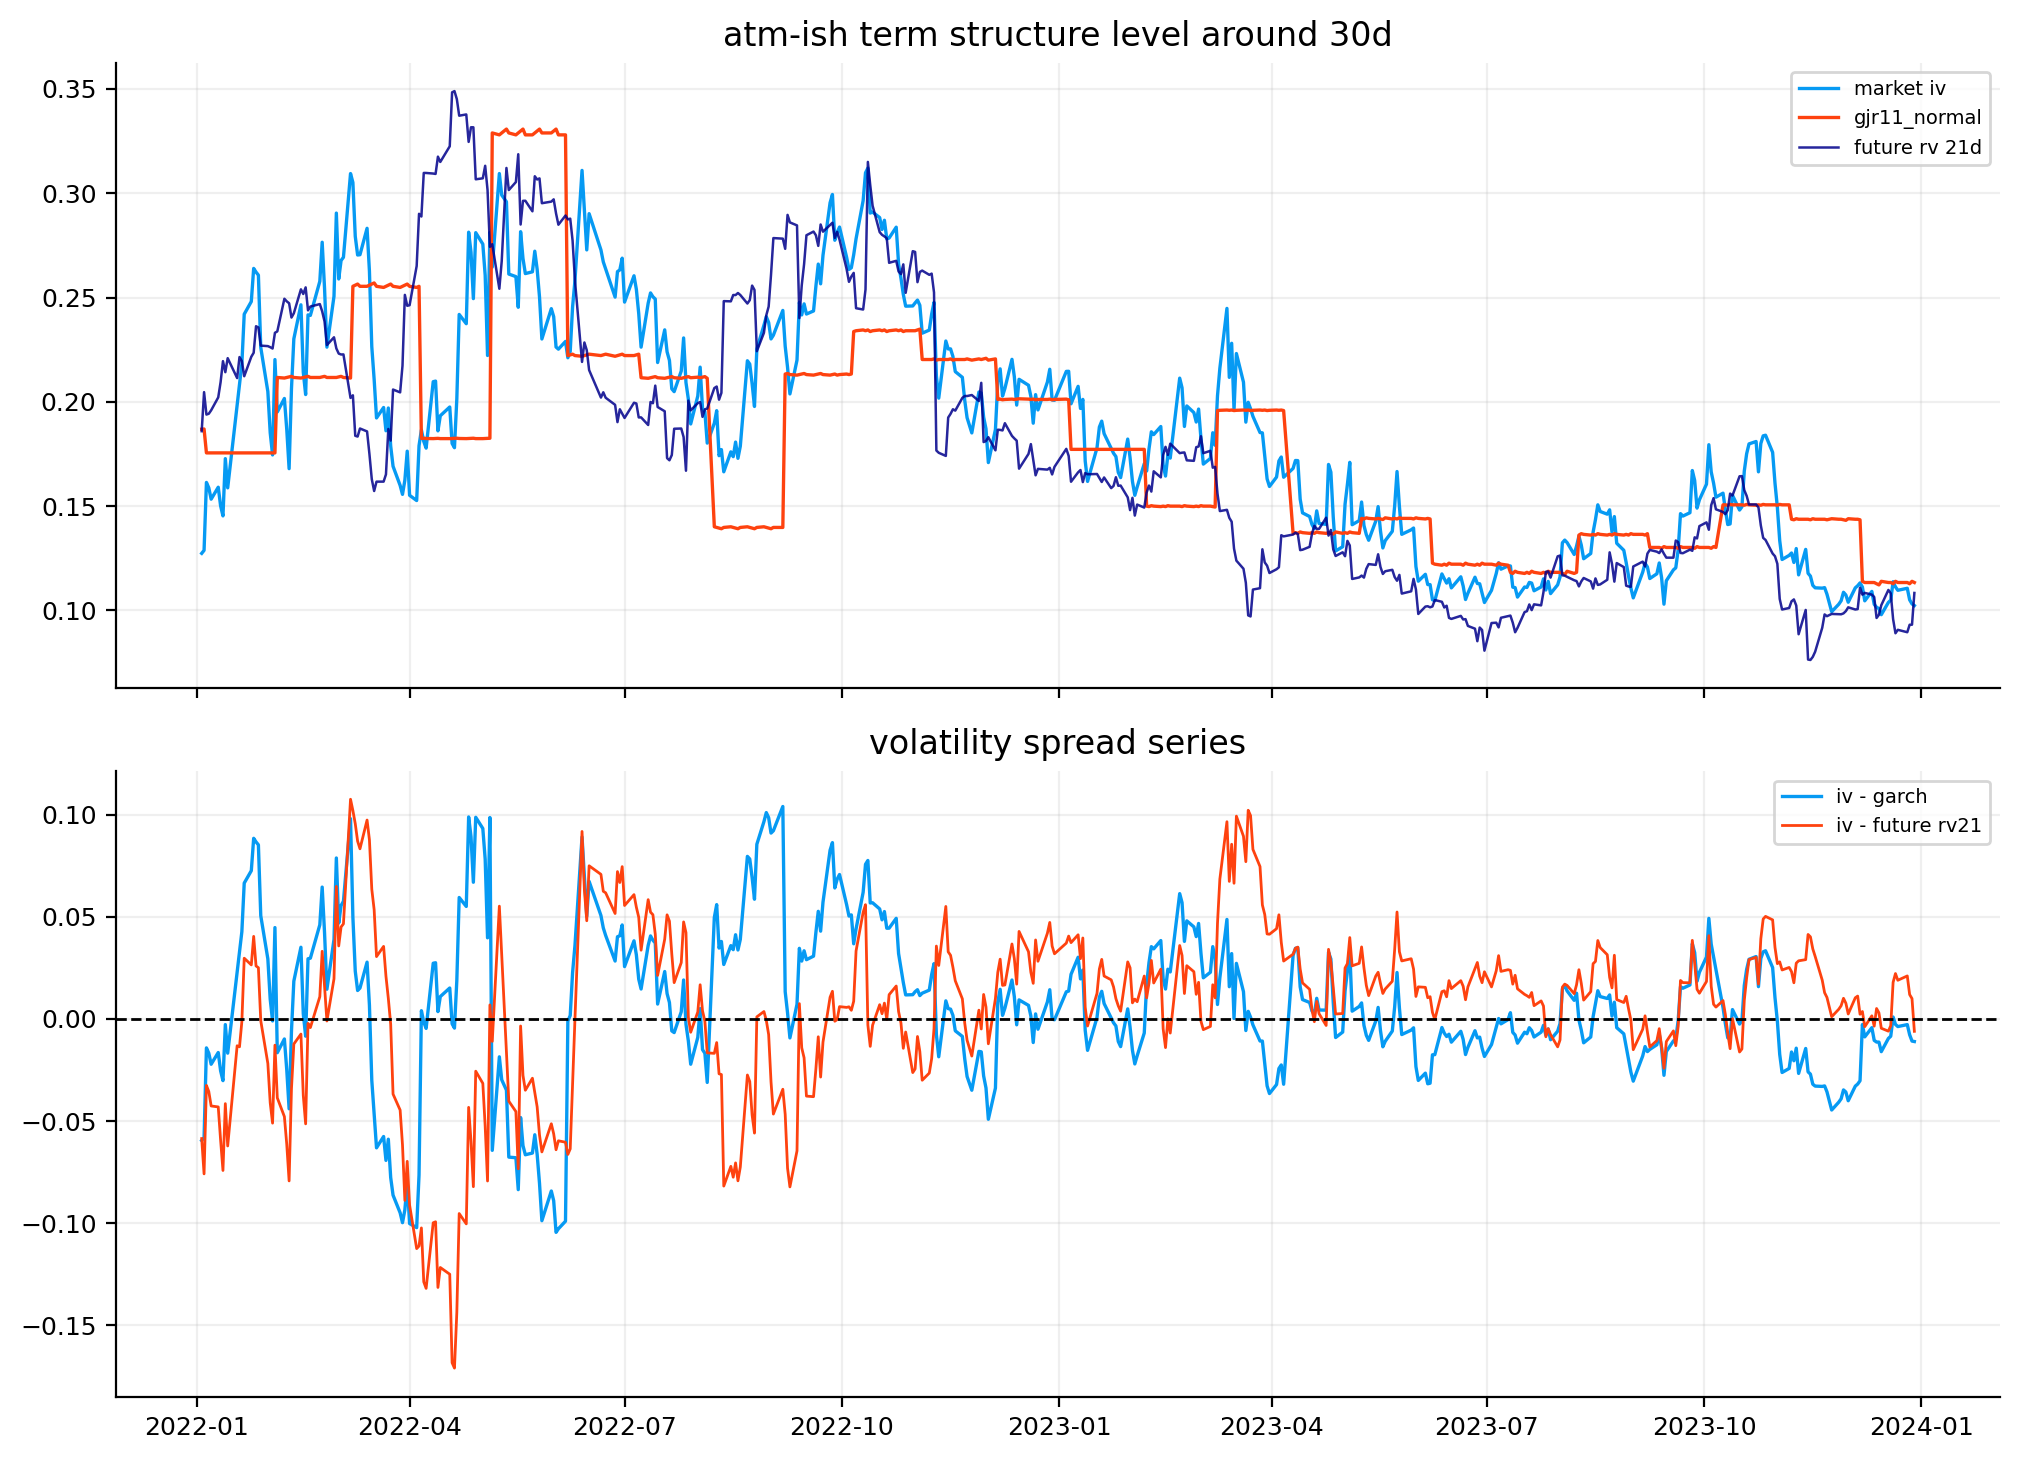

,model,r2,const,market_iv,garch_iv
0,future_rv21_on_iv,0.618830,0.002573,0.957741,NaN
1,future_rv21_on_garch,0.461029,0.016746,NaN,0.914599
2,future_rv21_on_both,0.636444,-0.011829,0.773456,0.271161


In [32]:
vrp_panel = (
    df_term[(df_term["tau_days"] >= 18) & (df_term["tau_days"] <= 45)]
    .groupby("trade_date", as_index=False)
    .apply(lambda g: g.sort_values(["tau_days"]).iloc[(g["tau_days"] - 30.0).abs().argmin()])
    .reset_index(drop=True)
    .copy()
)

if "rv_vol_fwd_21" not in vrp_panel.columns:
    vrp_panel = vrp_panel.merge(
        df_market[["trade_date", "rv_vol_fwd_21", "rv_vol_fwd_42"]],
        on="trade_date",
        how="left",
    )

vrp_panel["iv_minus_garch"] = vrp_panel["market_iv"] - vrp_panel["garch_iv"]
vrp_panel["iv_minus_rv"] = vrp_panel["market_iv"] - vrp_panel["rv_iv"]
vrp_panel["iv_minus_future_rv21"] = vrp_panel["market_iv"] - vrp_panel["rv_vol_fwd_21"]

enc = vrp_panel[["market_iv", "garch_iv", "rv_vol_fwd_21"]].replace([np.inf, -np.inf], np.nan).dropna()
X_iv = sm.add_constant(enc[["market_iv"]])
X_garch = sm.add_constant(enc[["garch_iv"]])
X_both = sm.add_constant(enc[["market_iv", "garch_iv"]])
res_iv = sm.OLS(enc["rv_vol_fwd_21"], X_iv).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
res_garch = sm.OLS(enc["rv_vol_fwd_21"], X_garch).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
res_both = sm.OLS(enc["rv_vol_fwd_21"], X_both).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

fig, axes = plt.subplots(2, 1, figsize=(10.2, 7.4), sharex=True)
axes[0].plot(vrp_panel["trade_date"], vrp_panel["market_iv"], lw=1.2, label="market iv")
axes[0].plot(vrp_panel["trade_date"], vrp_panel["garch_iv"], lw=1.2, label=best_model_name)
axes[0].plot(vrp_panel["trade_date"], vrp_panel["rv_vol_fwd_21"], lw=0.9, alpha=0.85, label="future rv 21d")
axes[0].set_title("atm-ish term structure level around 30d")
axes[0].legend(loc="best")

axes[1].plot(vrp_panel["trade_date"], vrp_panel["iv_minus_garch"], lw=1.2, label="iv - garch")
axes[1].plot(vrp_panel["trade_date"], vrp_panel["iv_minus_future_rv21"], lw=1.0, label="iv - future rv21")
axes[1].axhline(0.0, lw=1.0, ls="--", c="black")
axes[1].set_title("volatility spread series")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()

display(pd.DataFrame(
    [
        {"model": "future_rv21_on_iv", "r2": float(res_iv.rsquared), "const": float(res_iv.params.get("const", np.nan)), "market_iv": float(res_iv.params.get("market_iv", np.nan))},
        {"model": "future_rv21_on_garch", "r2": float(res_garch.rsquared), "const": float(res_garch.params.get("const", np.nan)), "garch_iv": float(res_garch.params.get("garch_iv", np.nan))},
        {"model": "future_rv21_on_both", "r2": float(res_both.rsquared), "const": float(res_both.params.get("const", np.nan)), "market_iv": float(res_both.params.get("market_iv", np.nan)), "garch_iv": float(res_both.params.get("garch_iv", np.nan))},
    ]
))
